# Simplified Causal Study Analysis

This notebook provides a streamlined interface for analyzing causal study results using the refactored visualization functions.

In [1]:
import os
import numpy as np
import pandas as pd
import warnings
import matplotlib.pyplot as plt
from datetime import datetime

# Import necessary functions
from causal_evaluation import load_study_results
from causal_visualization import generate_all_plots

# Filter out specific FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning, 
                       message="use_inf_as_na option is deprecated")
warnings.filterwarnings("ignore", category=FutureWarning, 
                       message="When grouping with a length-1 list-like")

## 1. Configuration

Set the paths and parameters for the analysis.

In [2]:
# Set the main study folder path
main_study_folder = "full_study_results_2025-04-05_14-00-23"

# Create a results folder for the analysis
results_folder = f"analysis_results_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"
os.makedirs(results_folder, exist_ok=True)

# Optionally, specify which studies to analyze
# If None, all *_study folders in the main_study_folder will be processed
studies = None  # e.g., ['auto_study', 'cross_study', 'noise_study']

## 2. Load Data and Generate Plots

Load the study results and generate all plots.

Loading study results and generating all plots...
Detecting studies in folder...
Found studies: ['auto_study', 'cross_study', 'noise_study', 'n_boot_study', 'T_study']
Loading study results from full_study_results_2025-04-05_14-00-23...
Found 5 substudy folders
Processing substudy: auto_study
  Processing parameter value: 0.01
  Processing parameter value: 0.06157894736842105
  Processing parameter value: 0.1131578947368421
  Processing parameter value: 0.16473684210526315
  Processing parameter value: 0.2163157894736842
  Processing parameter value: 0.26789473684210524
  Processing parameter value: 0.3194736842105263
  Processing parameter value: 0.37105263157894736
  Processing parameter value: 0.4226315789473684
  Processing parameter value: 0.47421052631578947
  Processing parameter value: 0.5257894736842105
  Processing parameter value: 0.5773684210526315
  Processing parameter value: 0.6289473684210526
  Processing parameter value: 0.6805263157894736
  Processing parameter value:

H:\thesis\code\causal_visualization.py:1823: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(12, 7))


    Processing param_val = 0.5257894736842105
    Processing param_val = 0.99
  Generating adjustment set plots...
Generating plots for sigmaN study...
  Generating error plots without CI...
  Generating effect comparison plots...
  Generating CI comparison plots...
  Generating bootstrap distribution plots...
    Processing param_val = 0.1
    Processing param_val = 1.6263157894736844
    Processing param_val = 3.0
  Generating adjustment set plots...
Generating plots for B study...
  Generating error plots without CI...
  Generating effect comparison plots...
  Generating CI comparison plots...
  Generating bootstrap distribution plots...
    Processing param_val = 10.0
    Processing param_val = 100.0
    Processing param_val = 500.0
  Generating adjustment set plots...
Generating plots for T study...
  Generating error plots without CI...
  Generating effect comparison plots...
  Generating CI comparison plots...
  Generating bootstrap distribution plots...
    Processing param_val

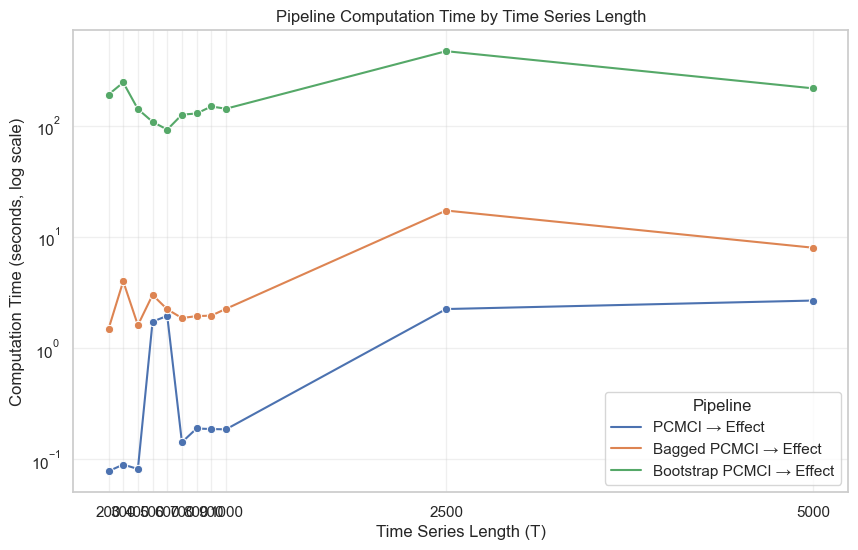

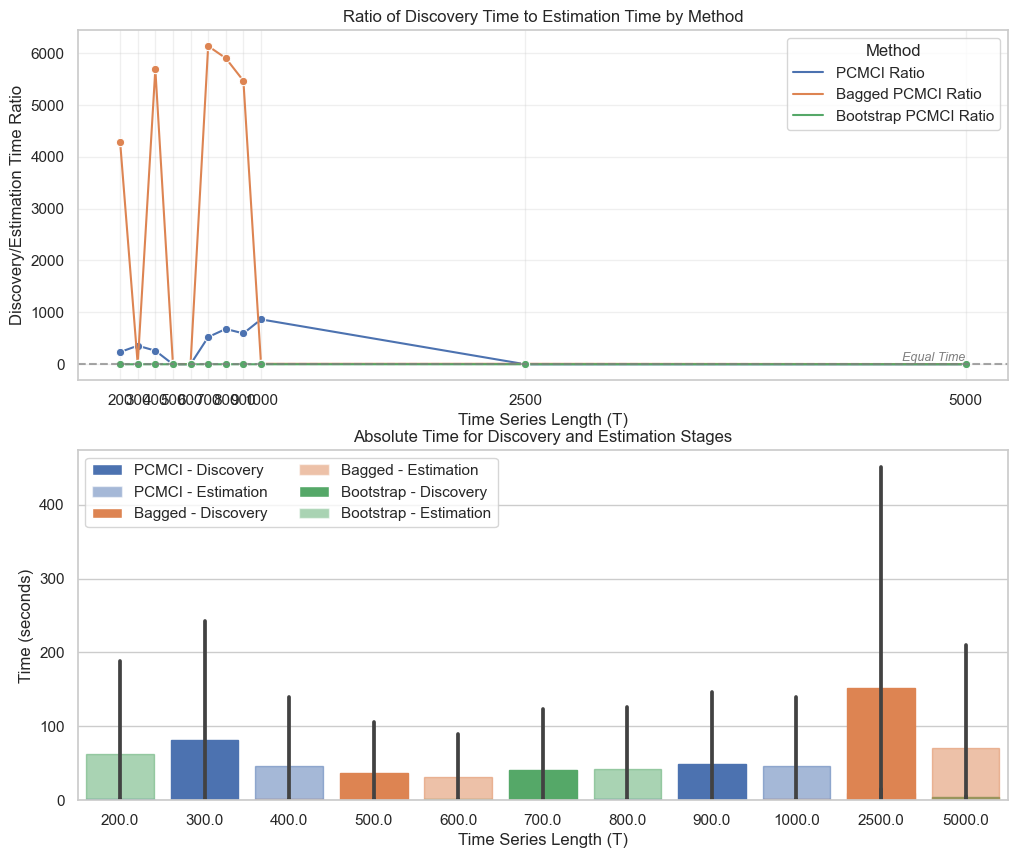

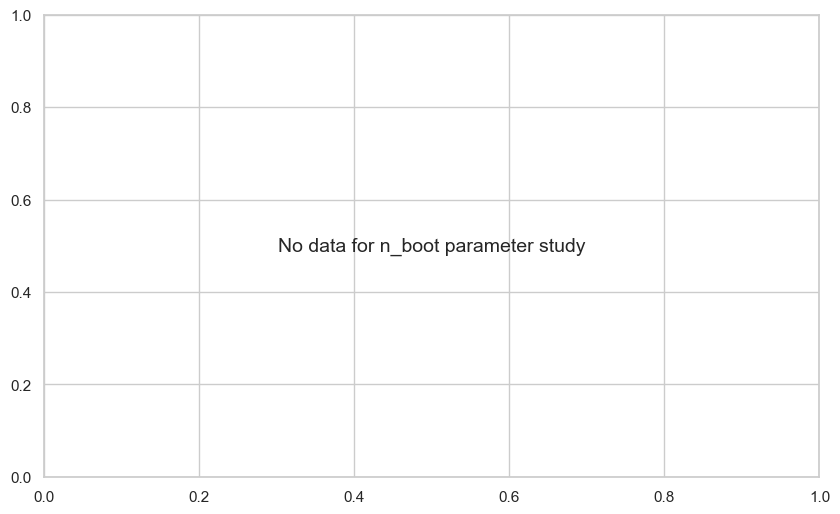

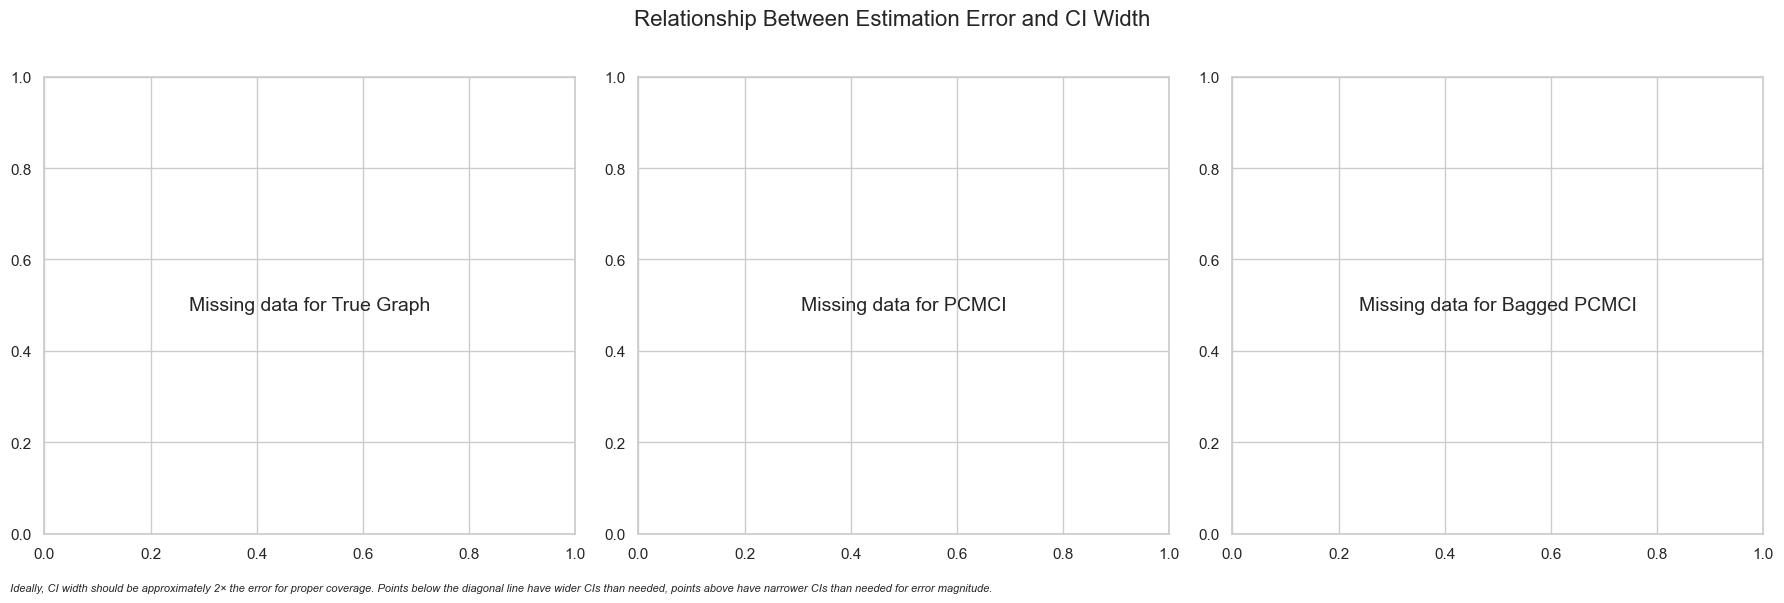

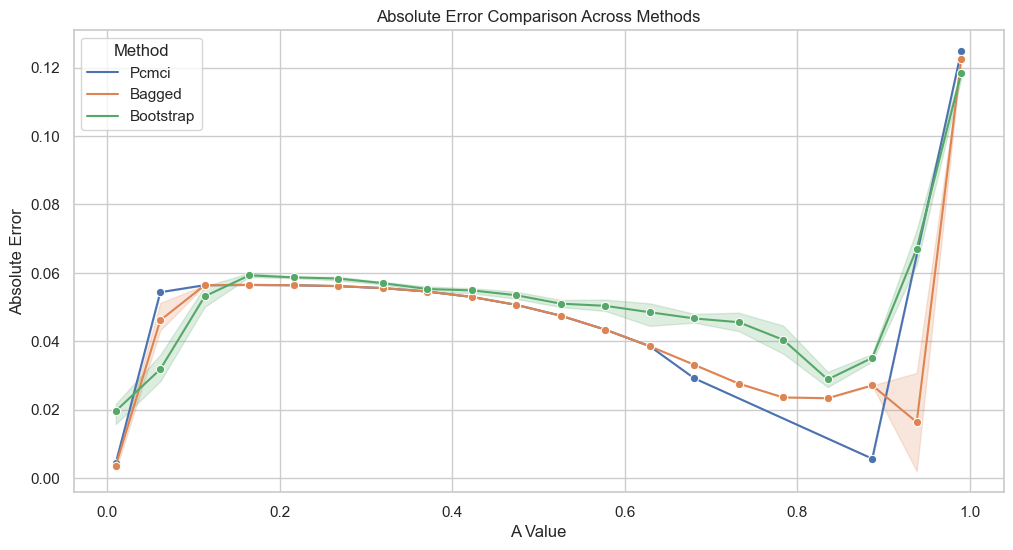

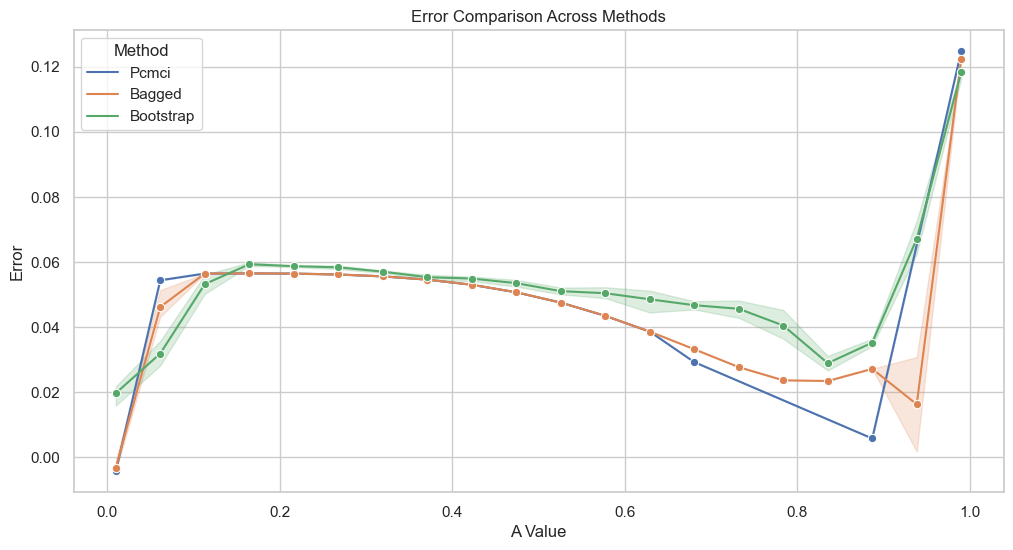

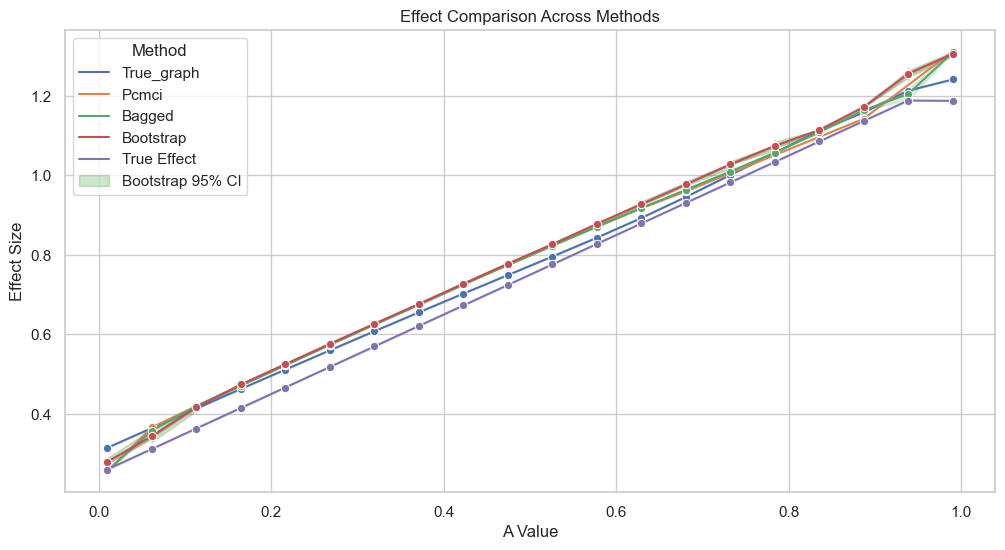

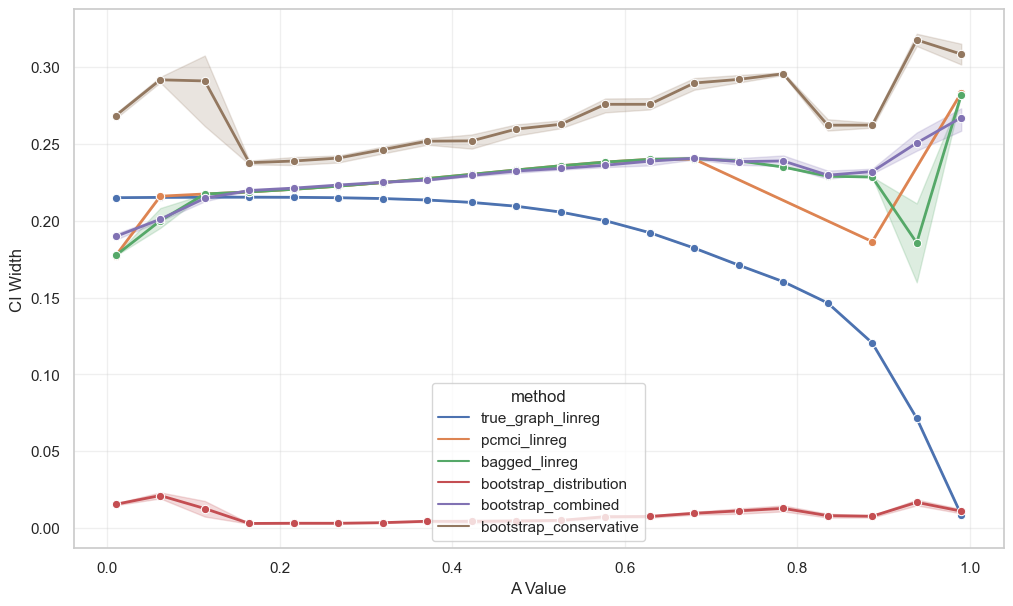

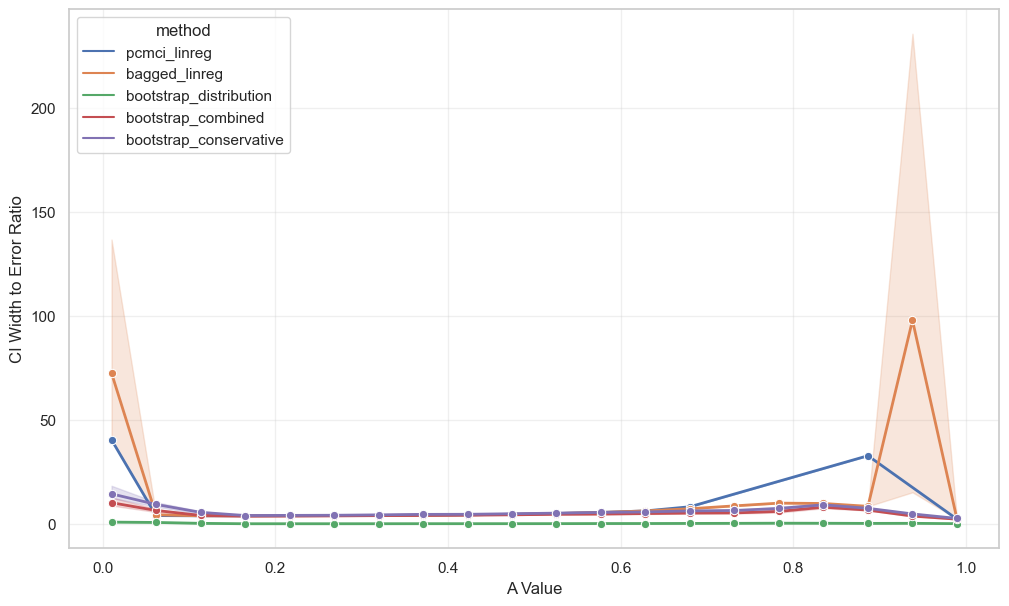

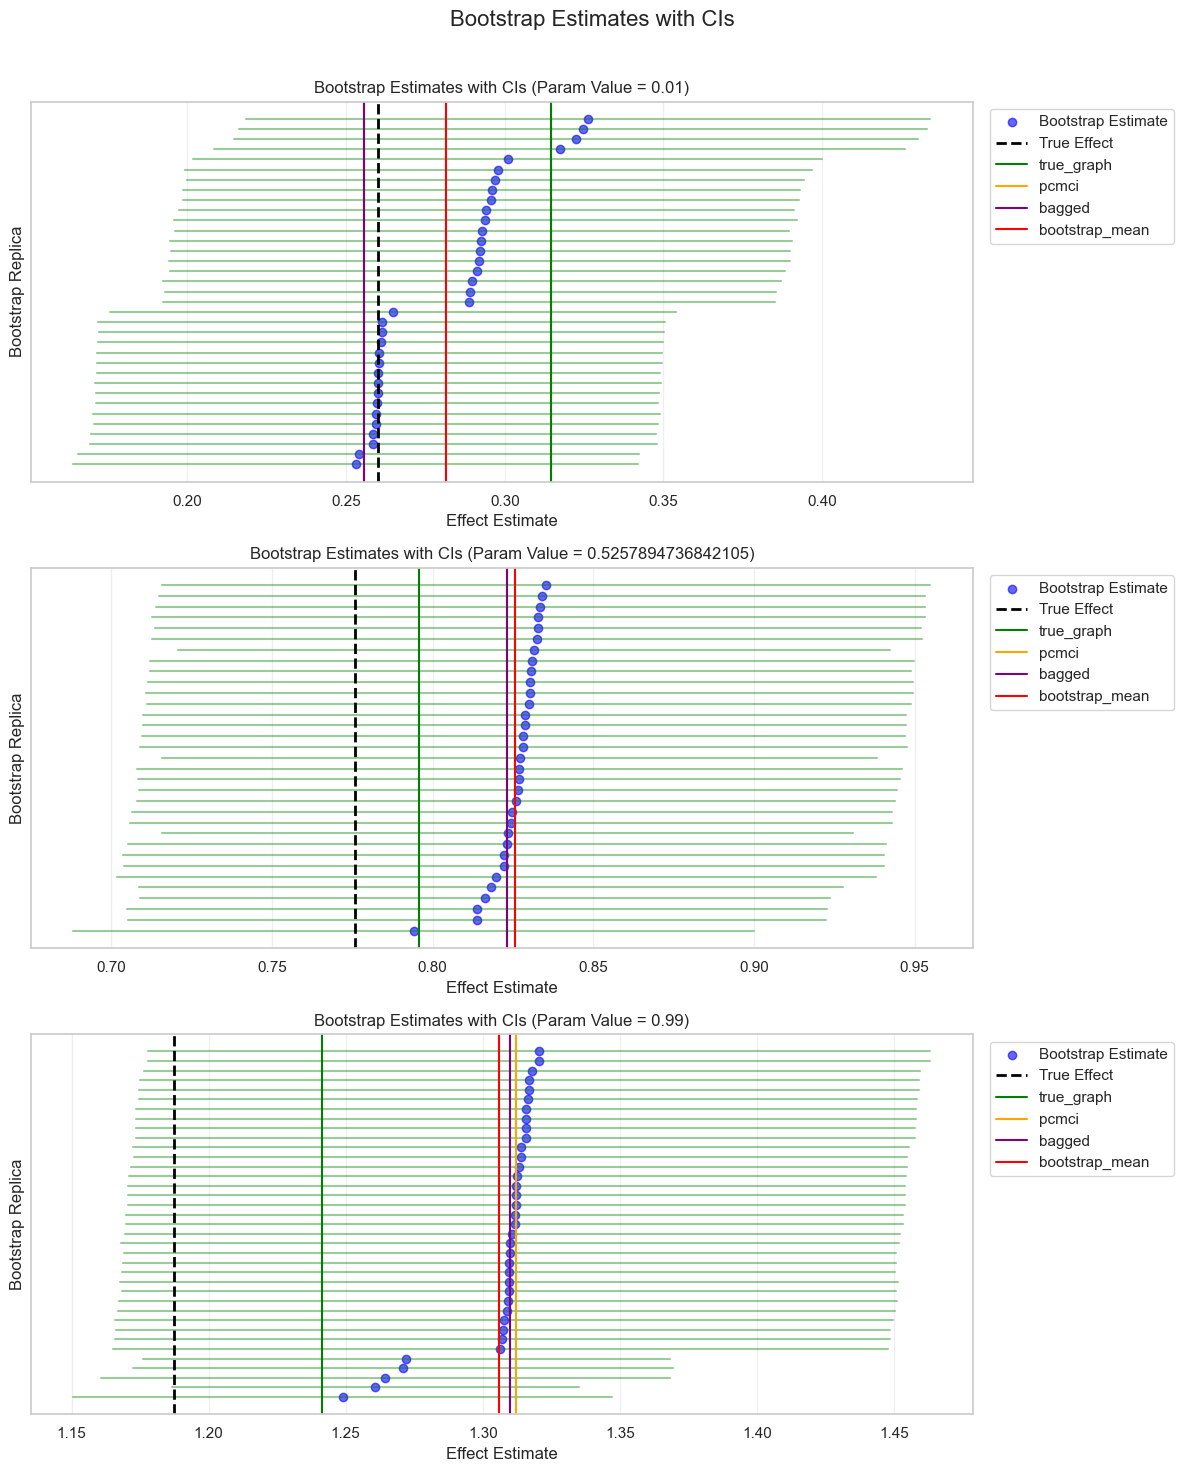

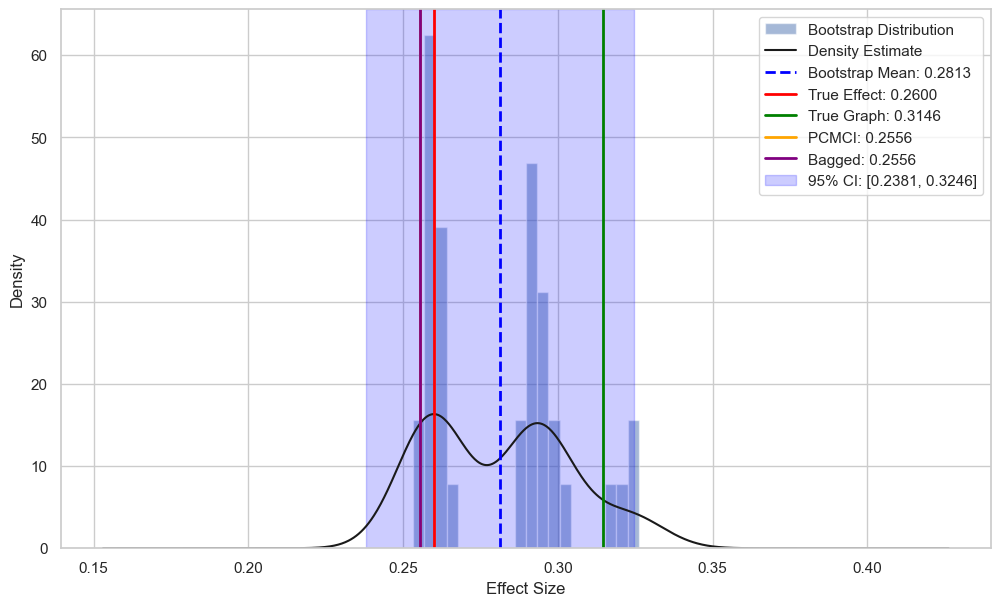

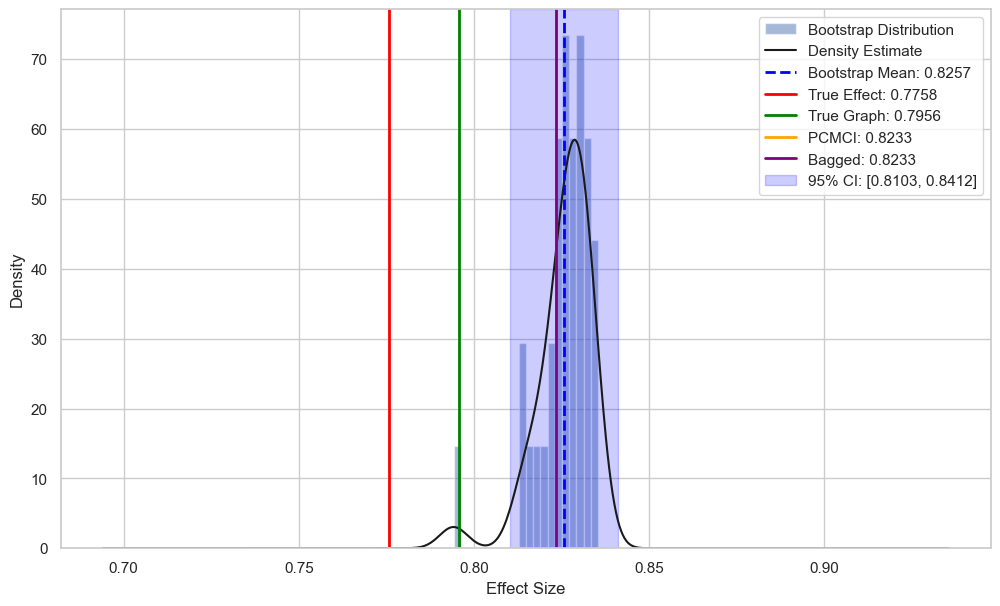

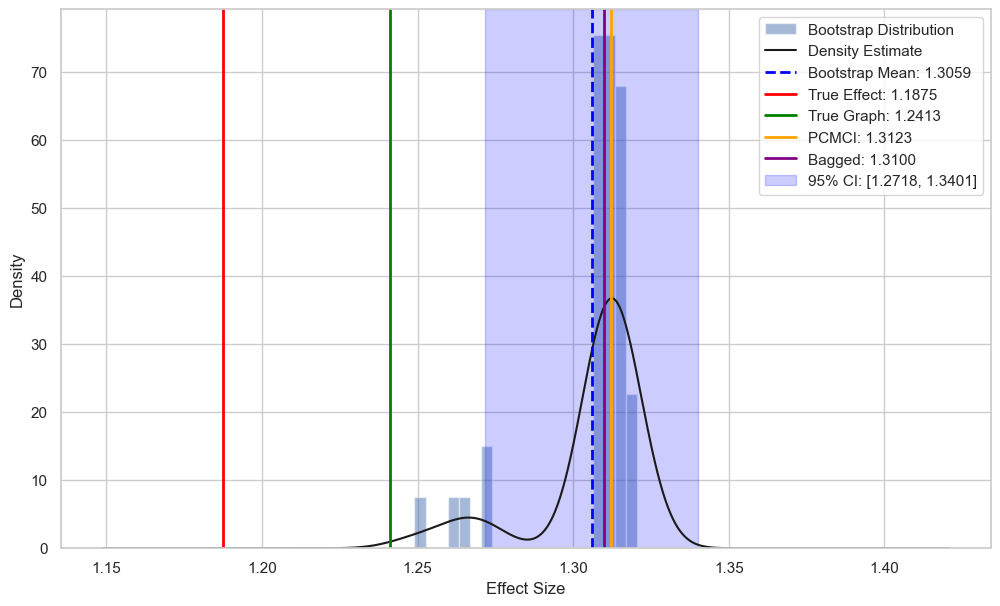

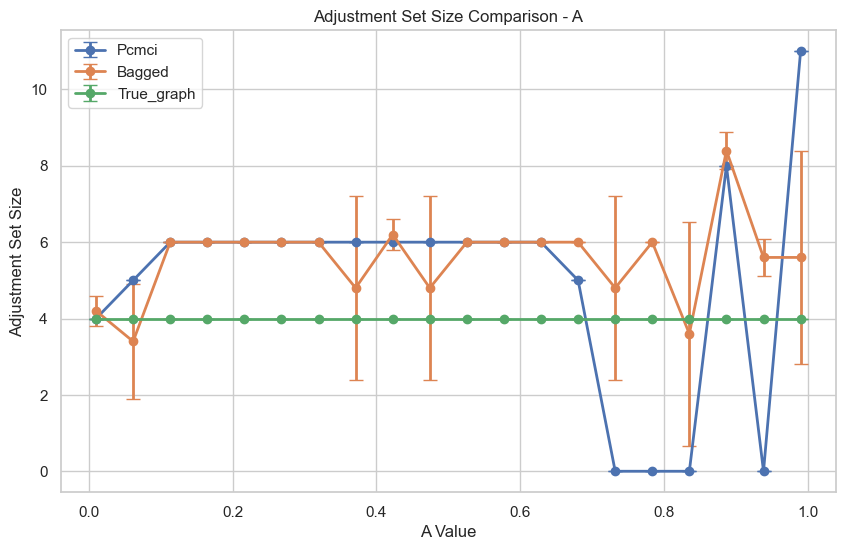

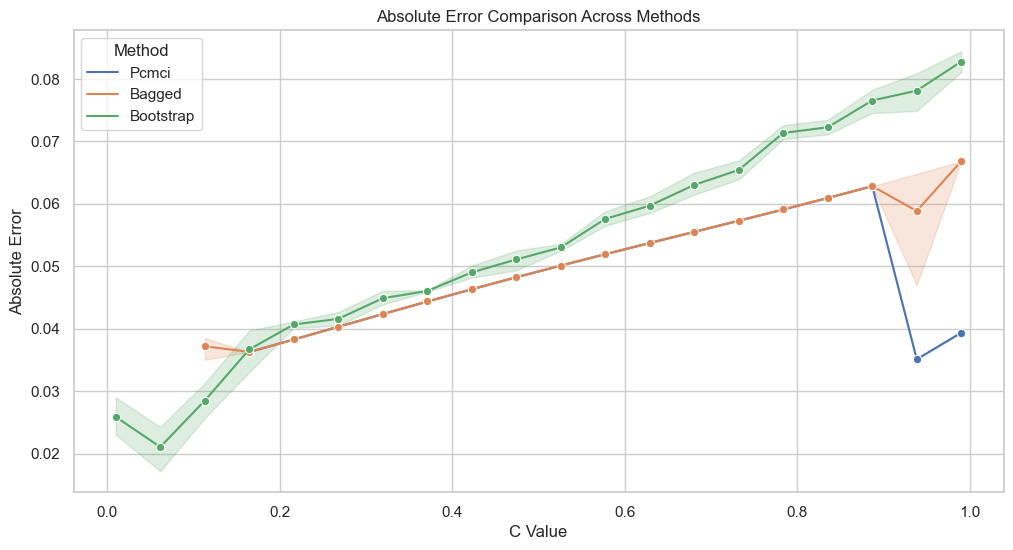

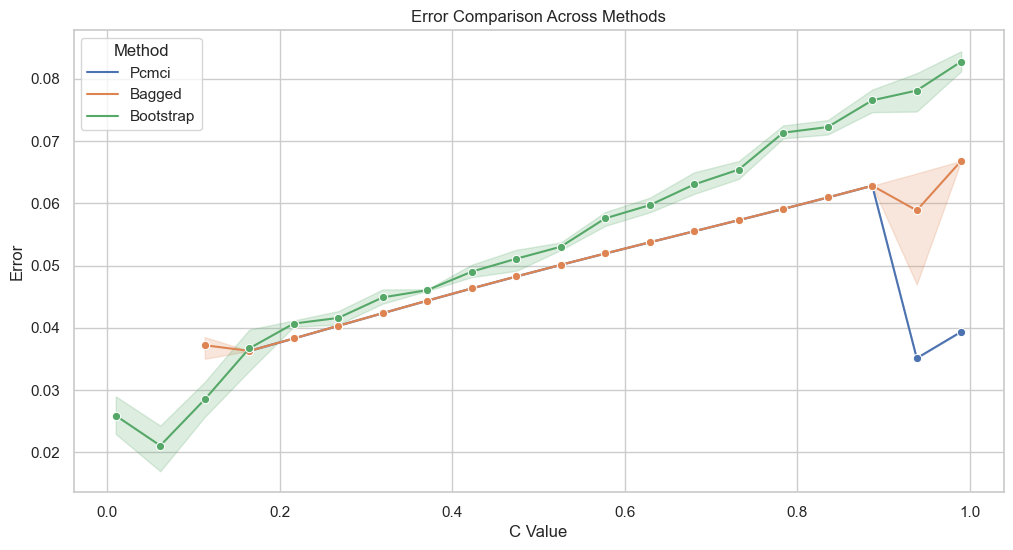

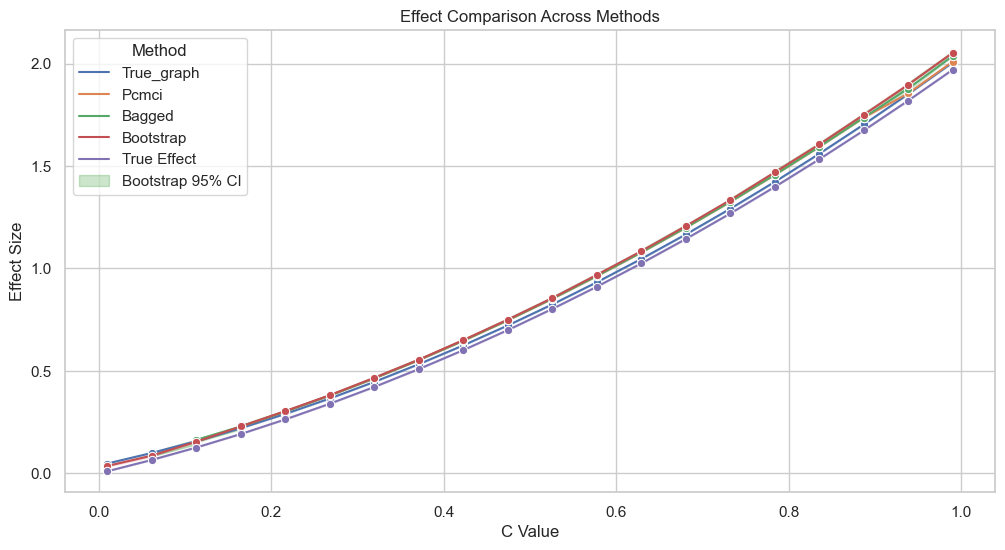

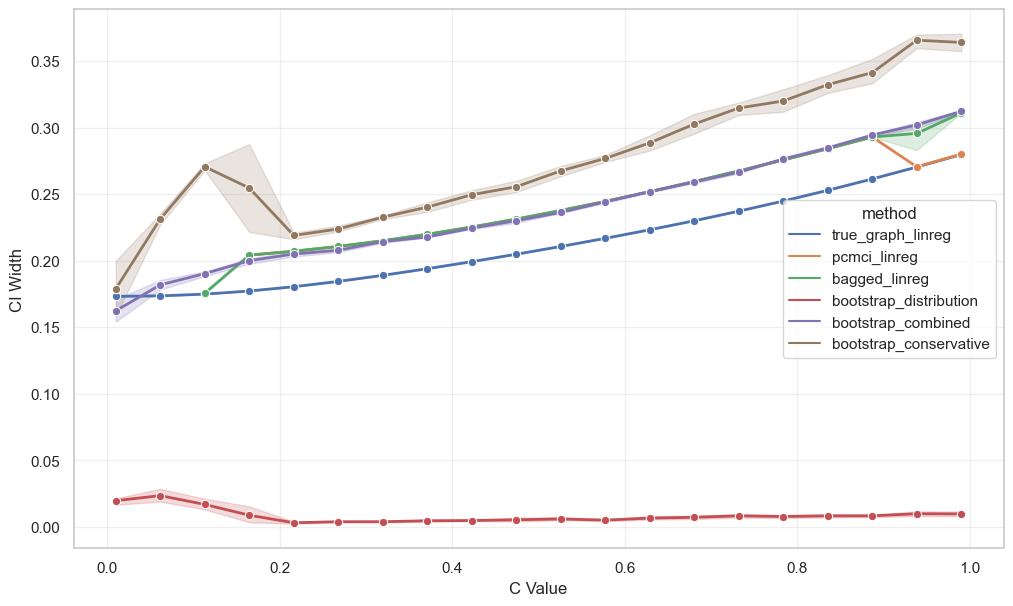

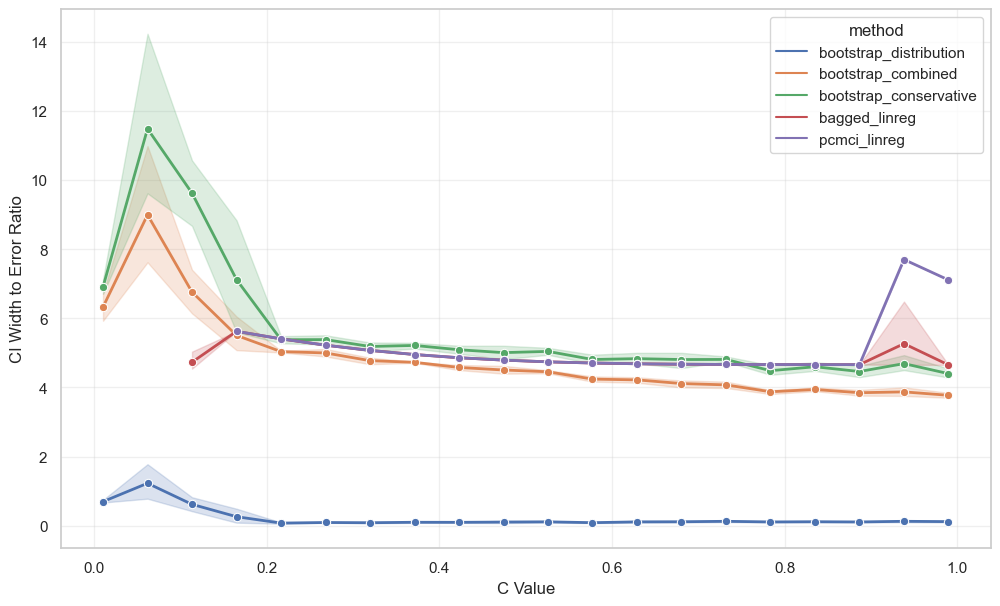

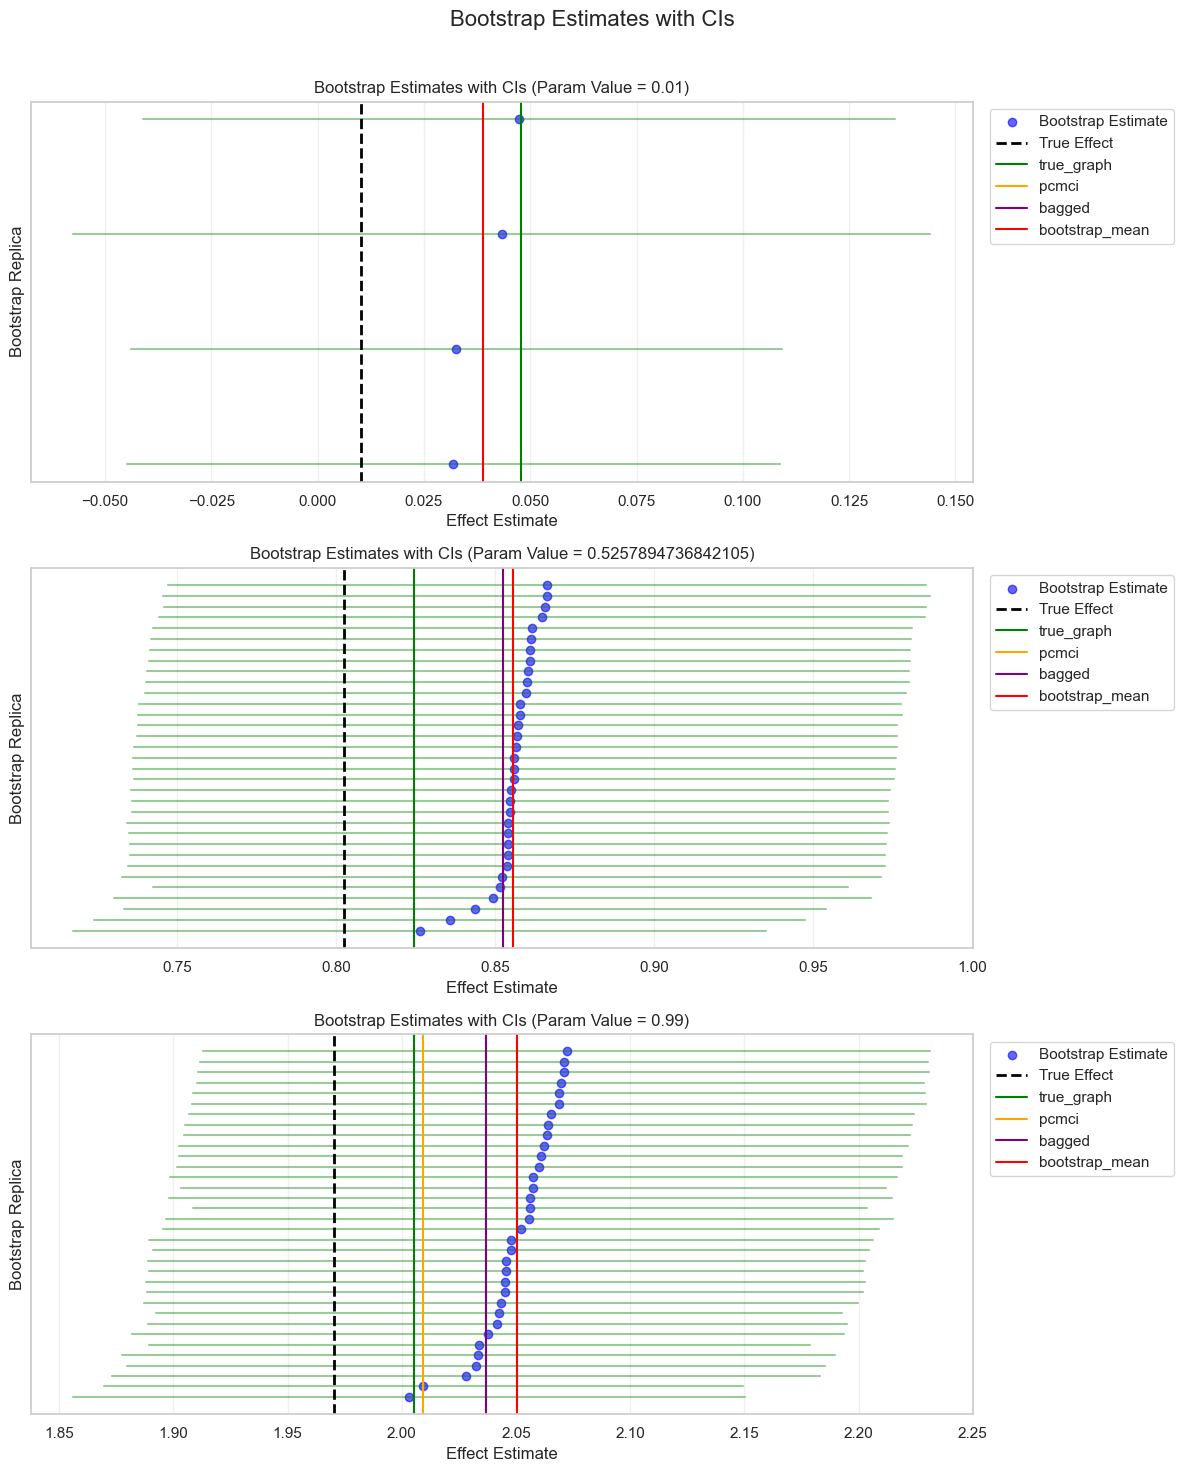

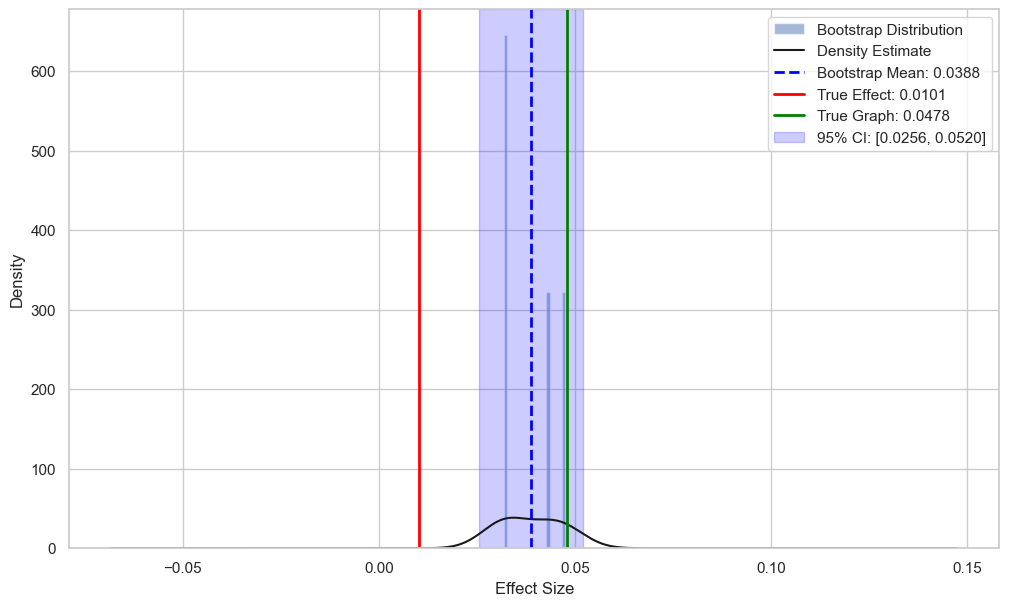

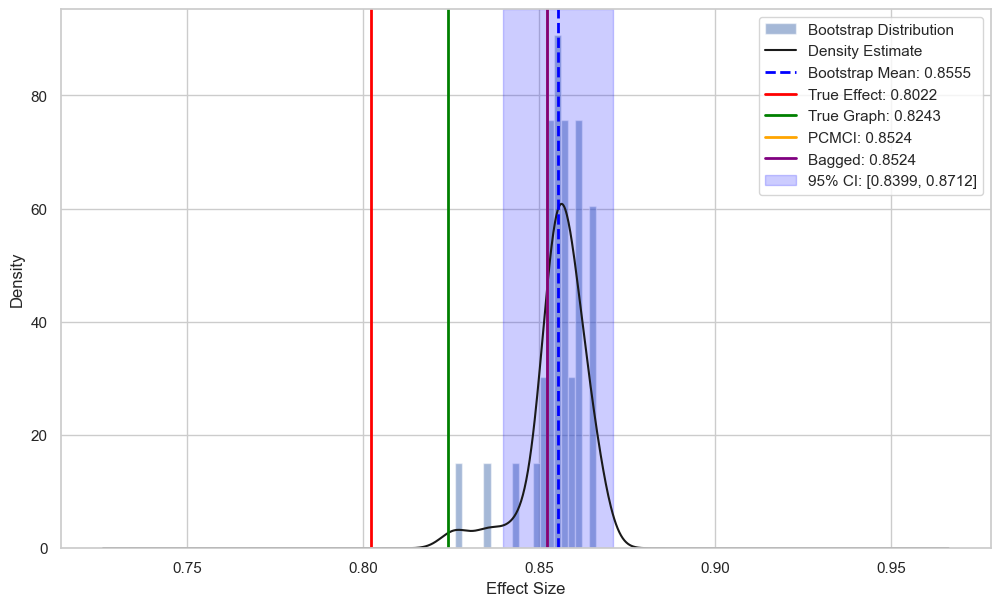

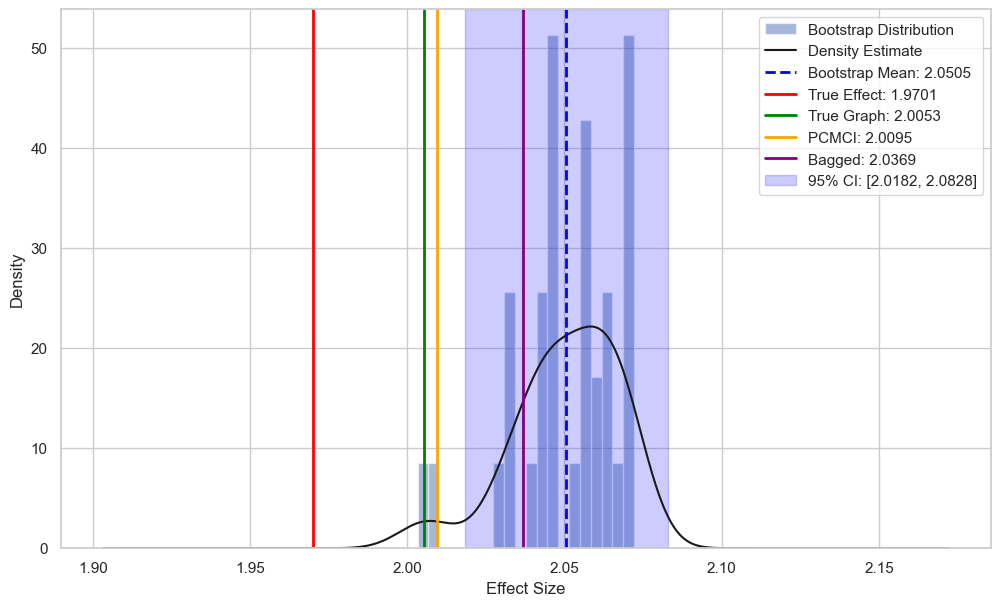

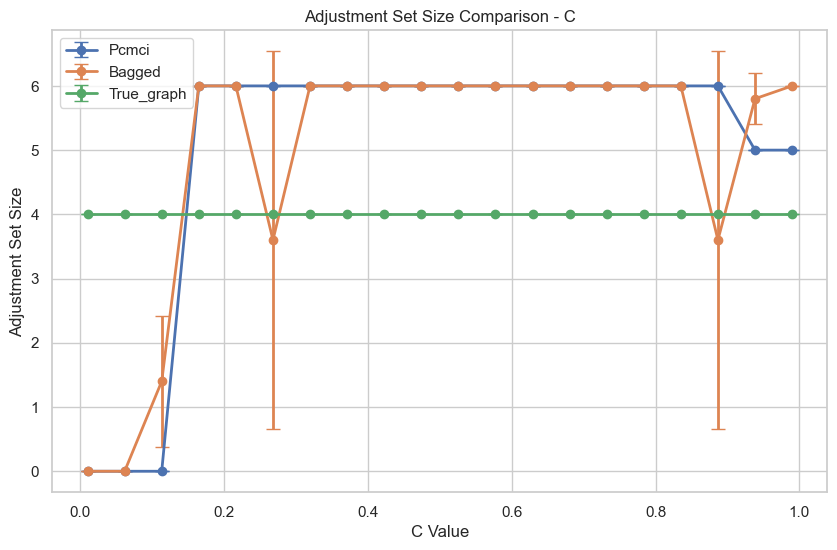

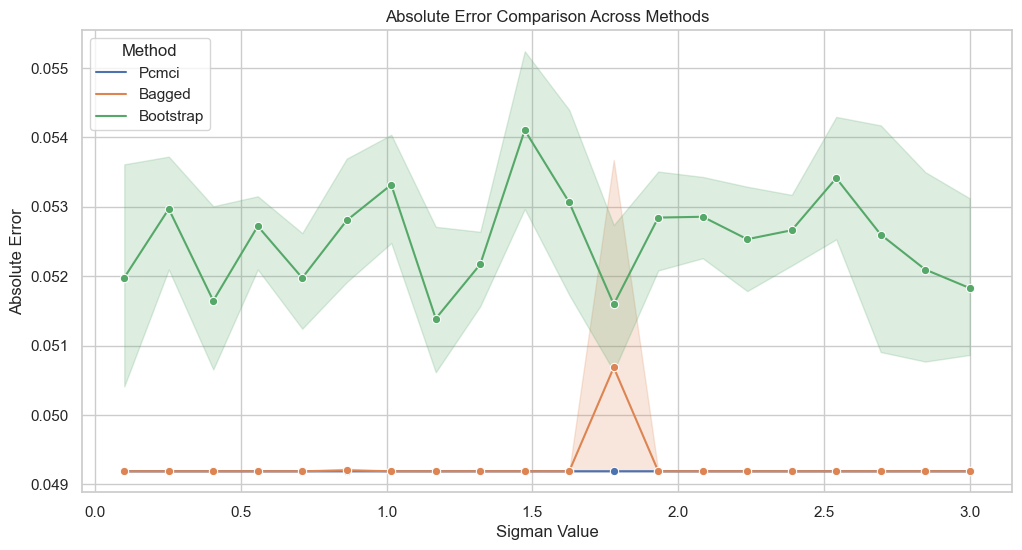

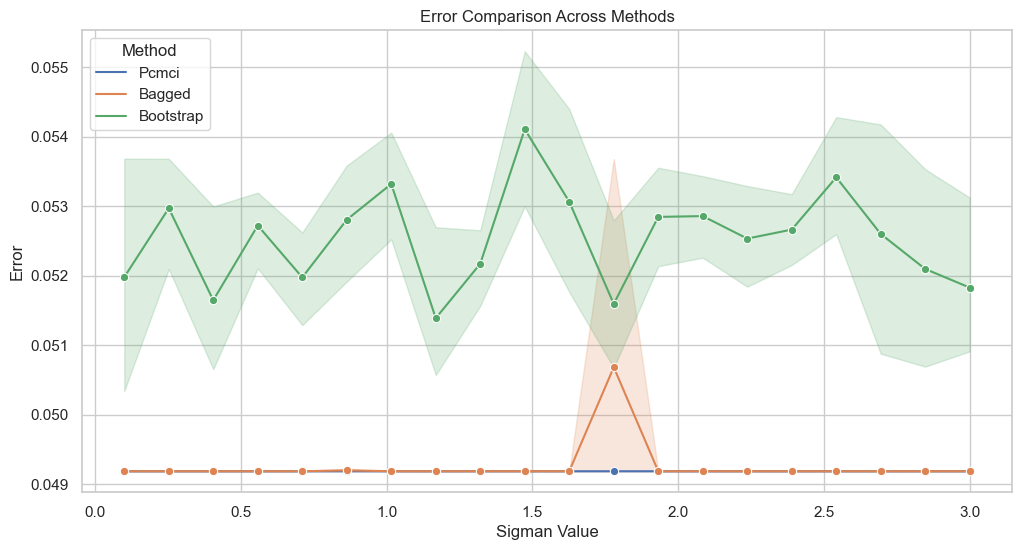

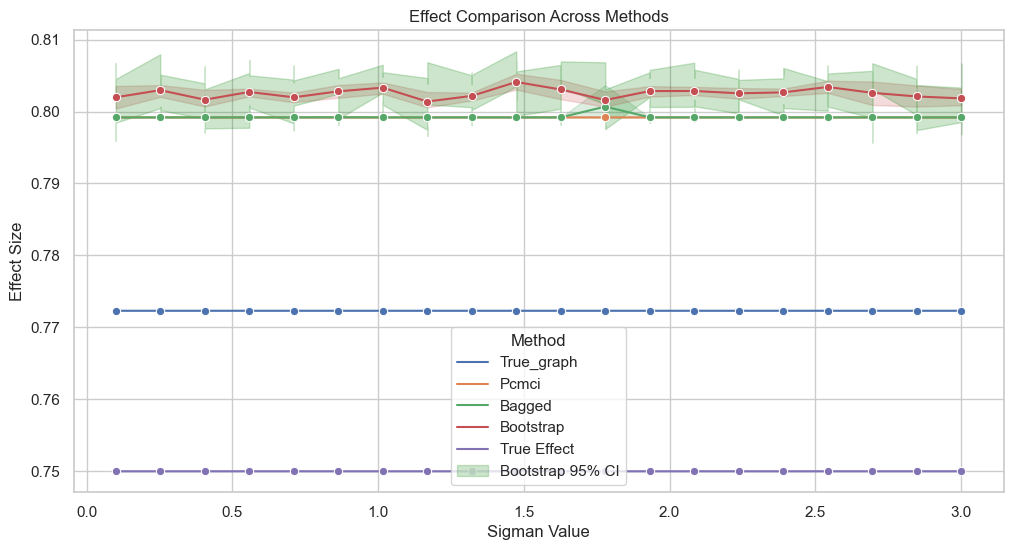

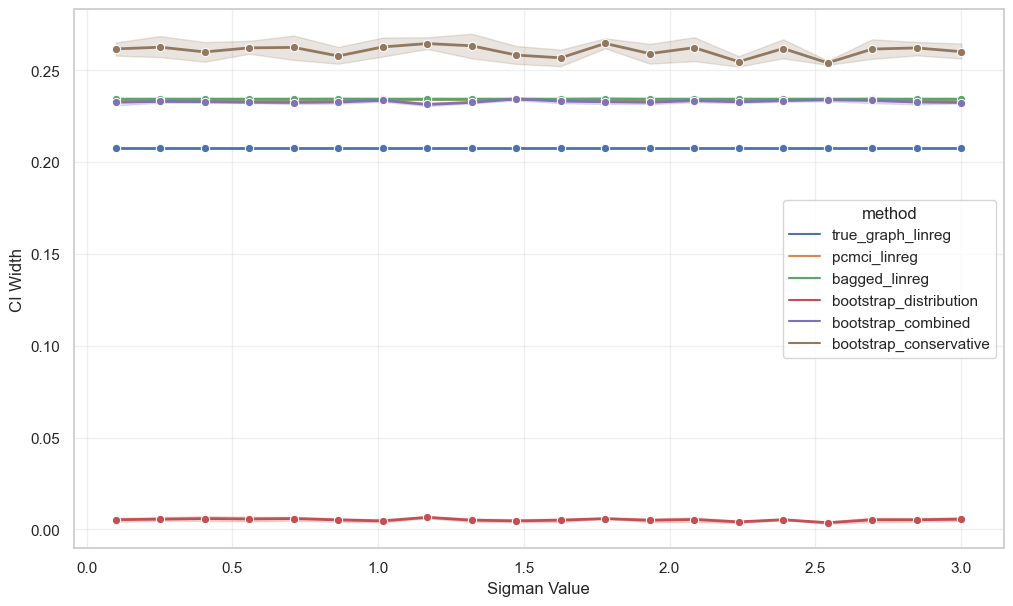

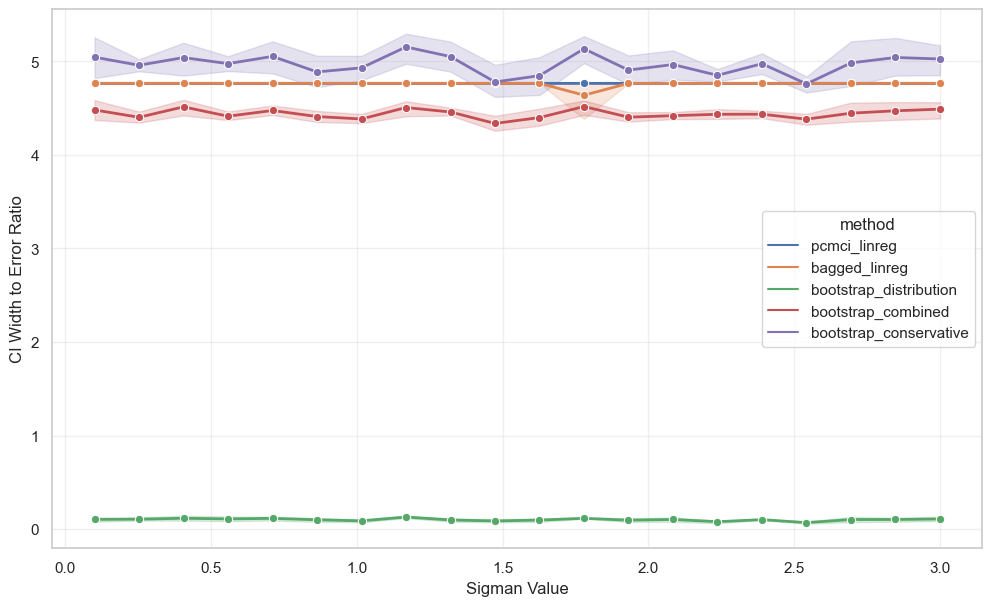

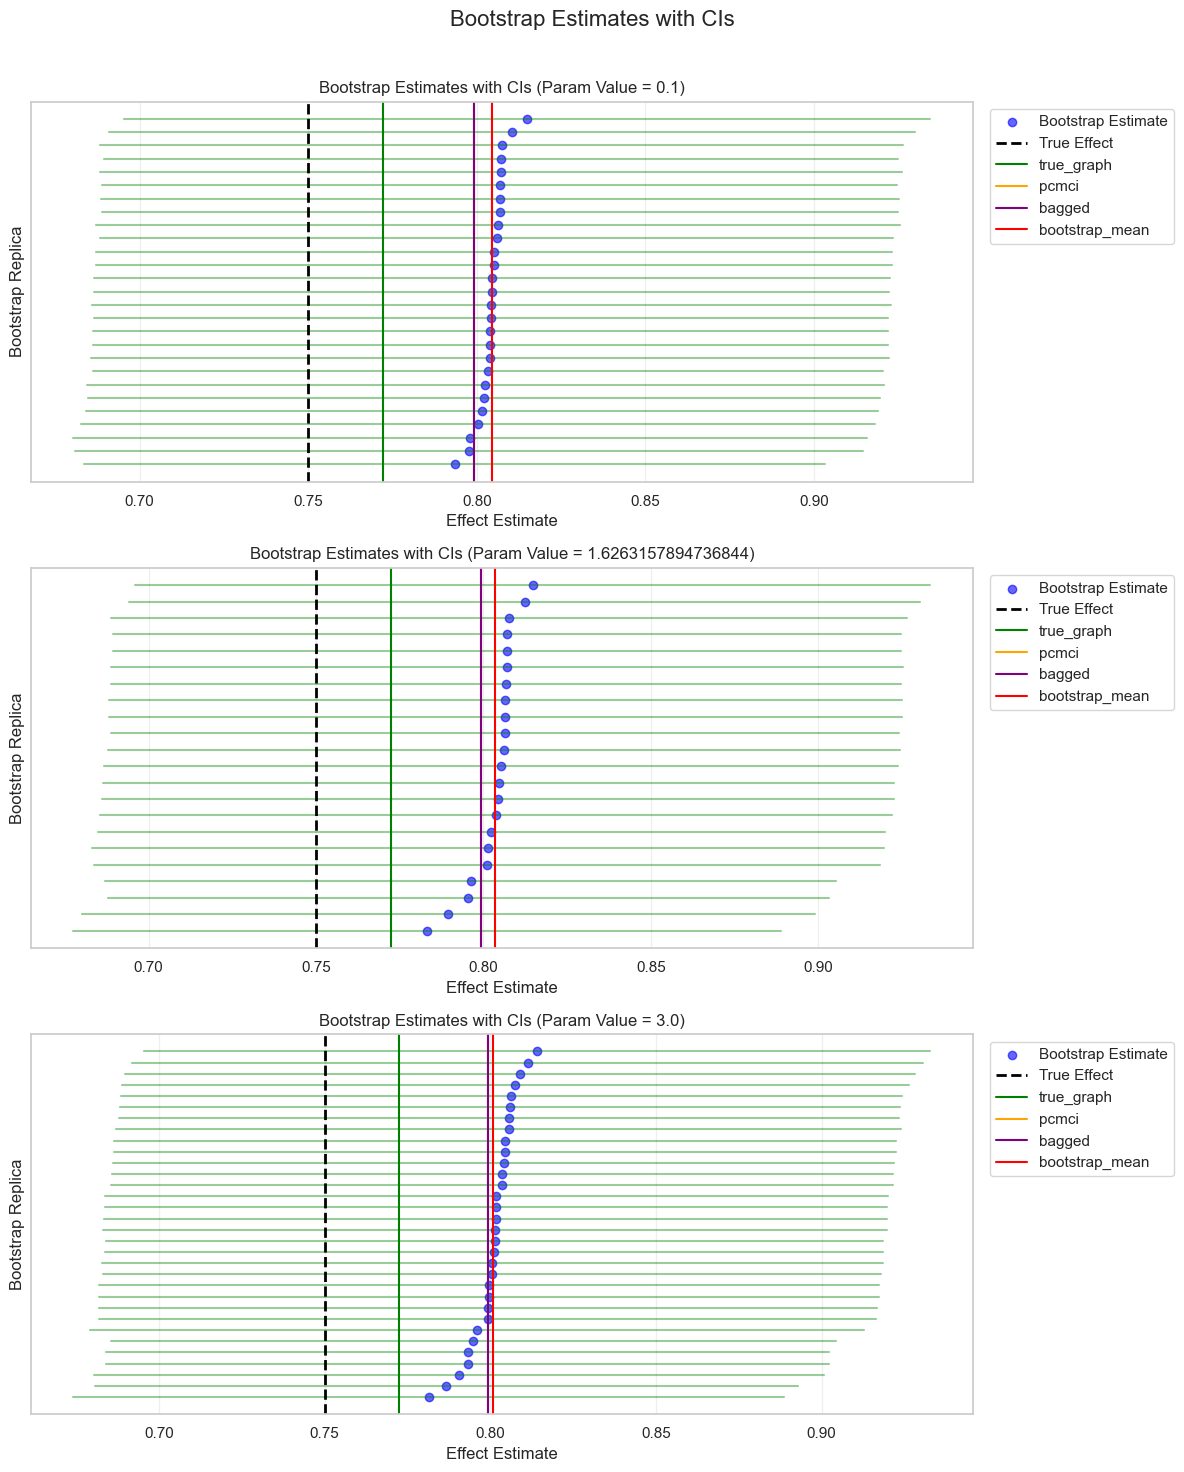

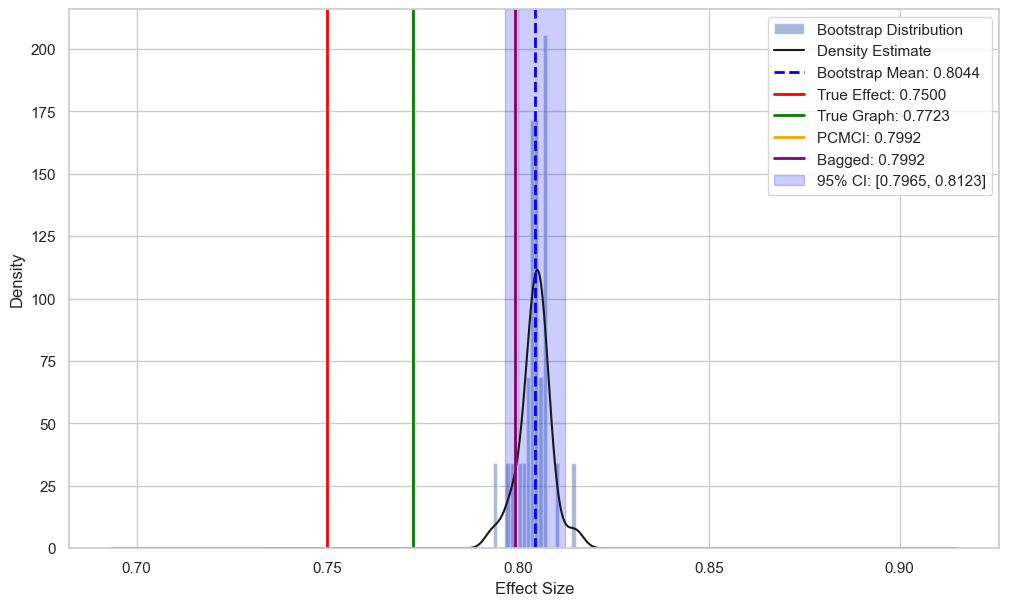

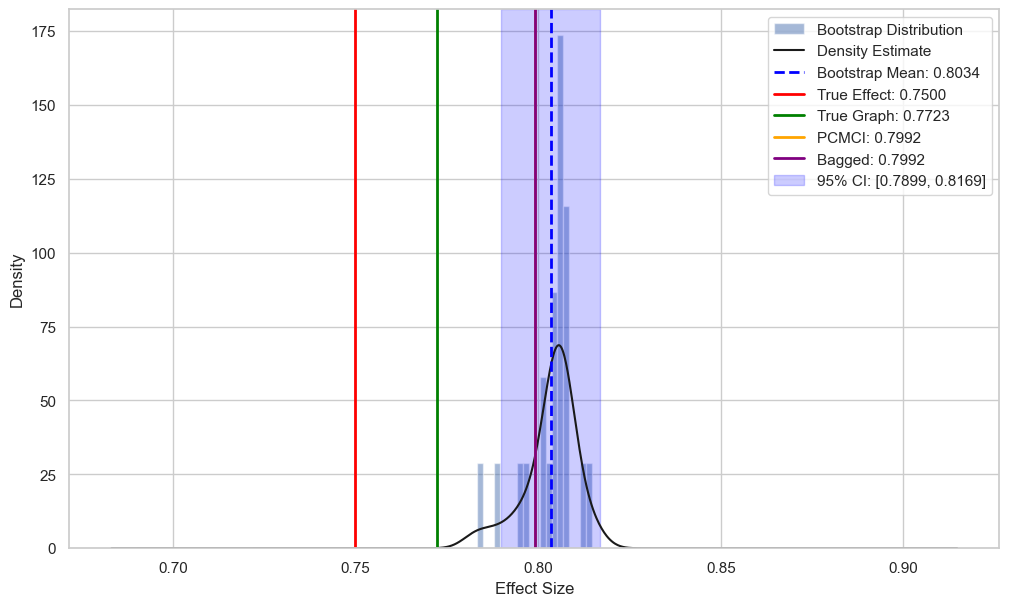

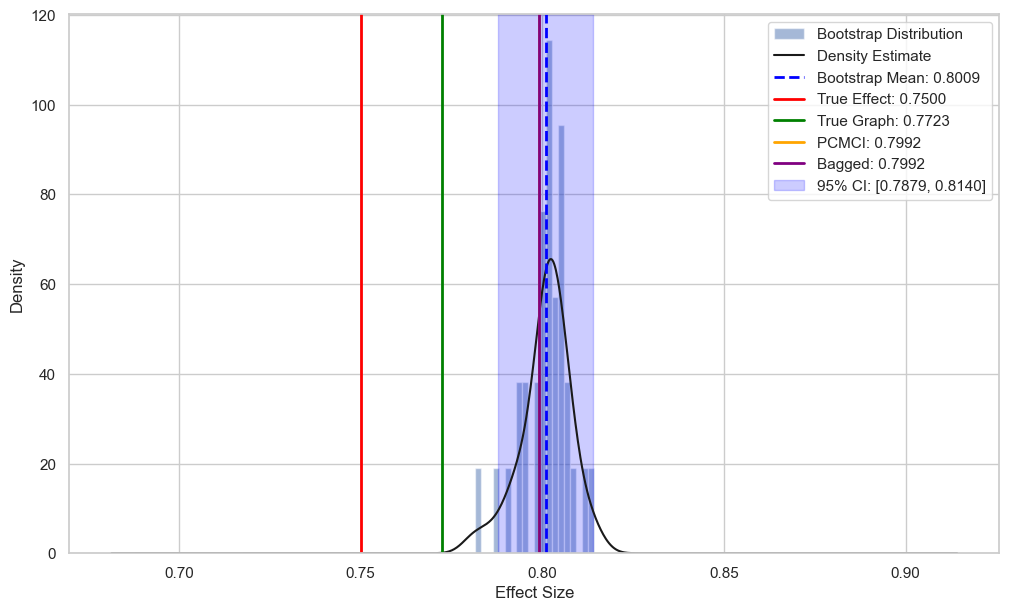

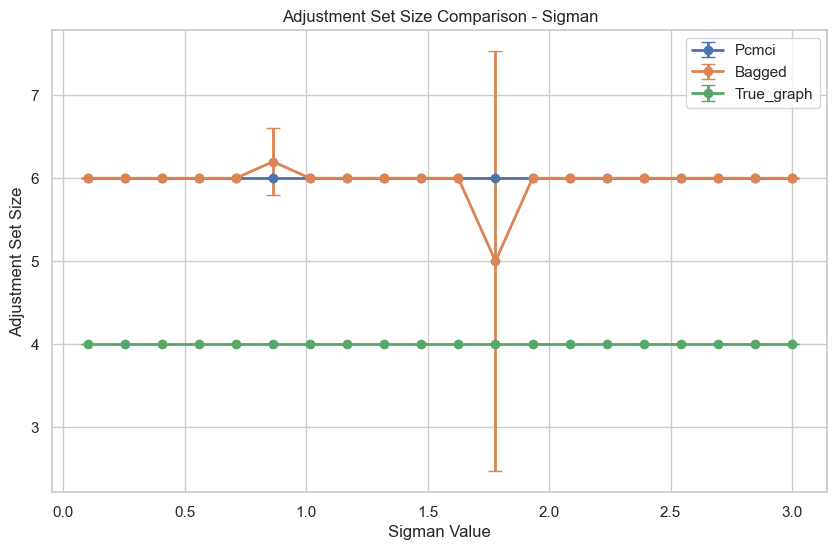

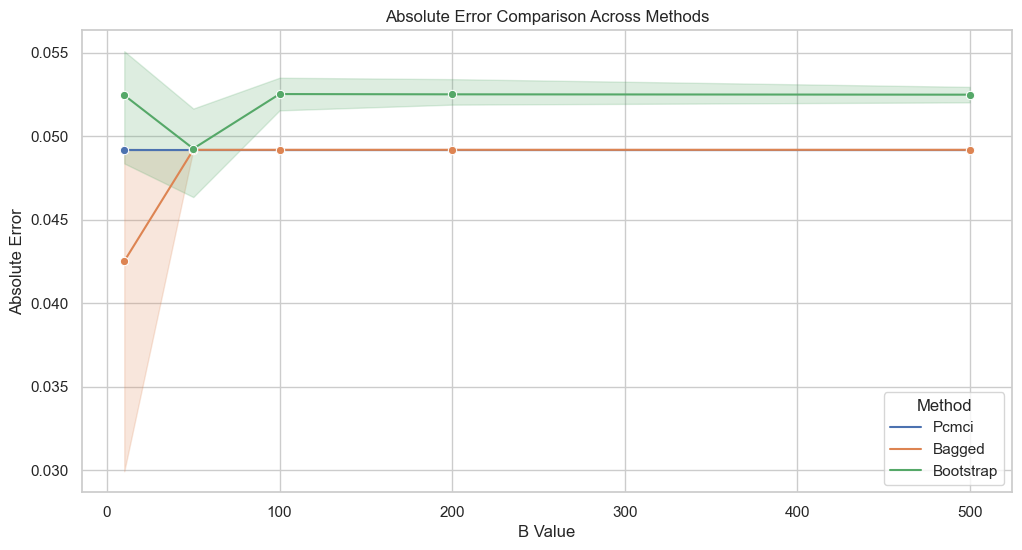

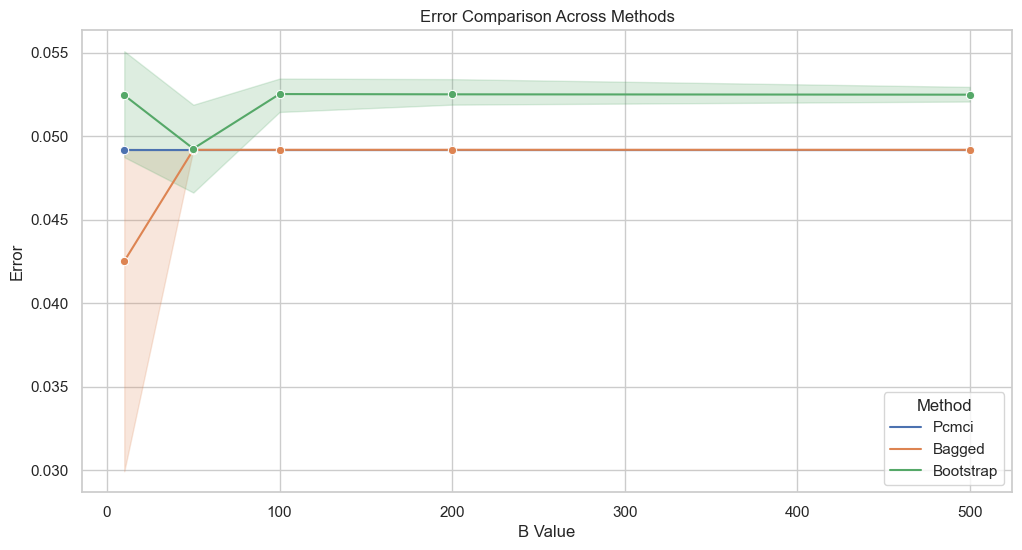

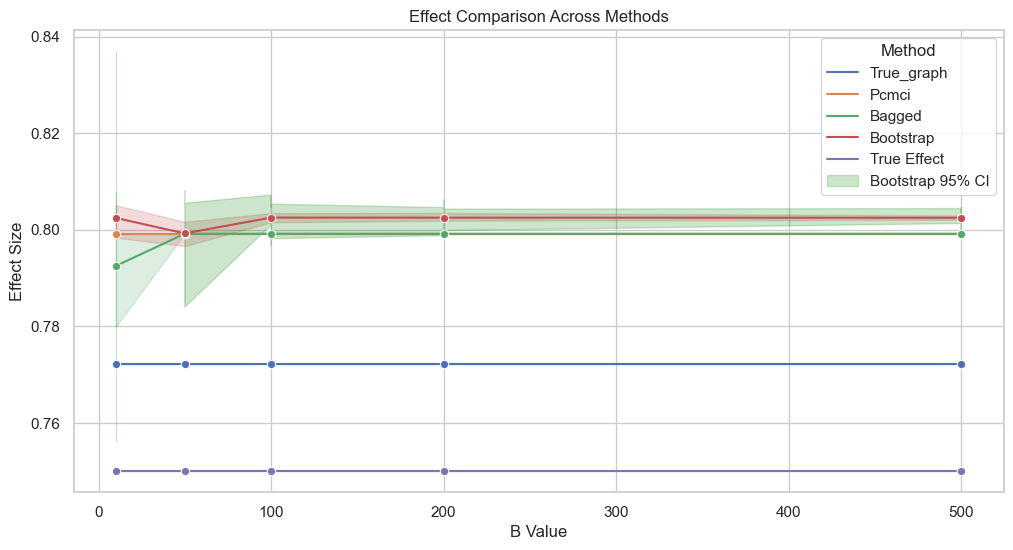

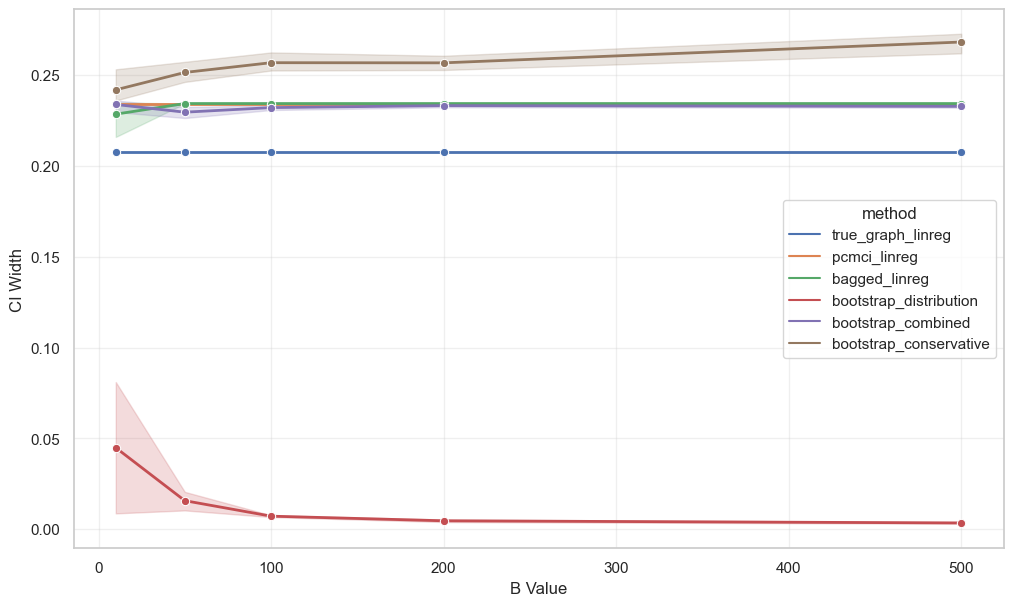

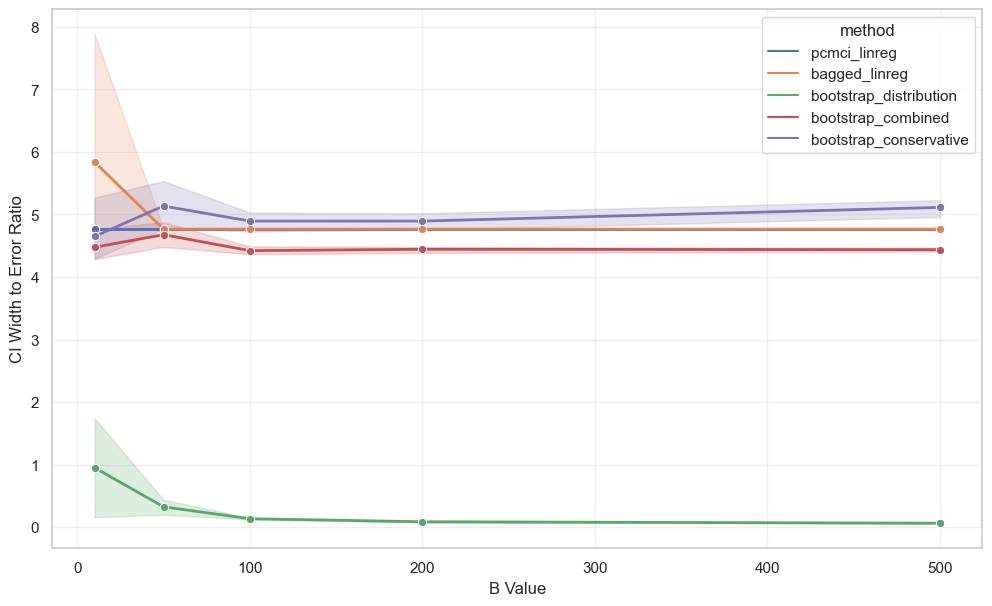

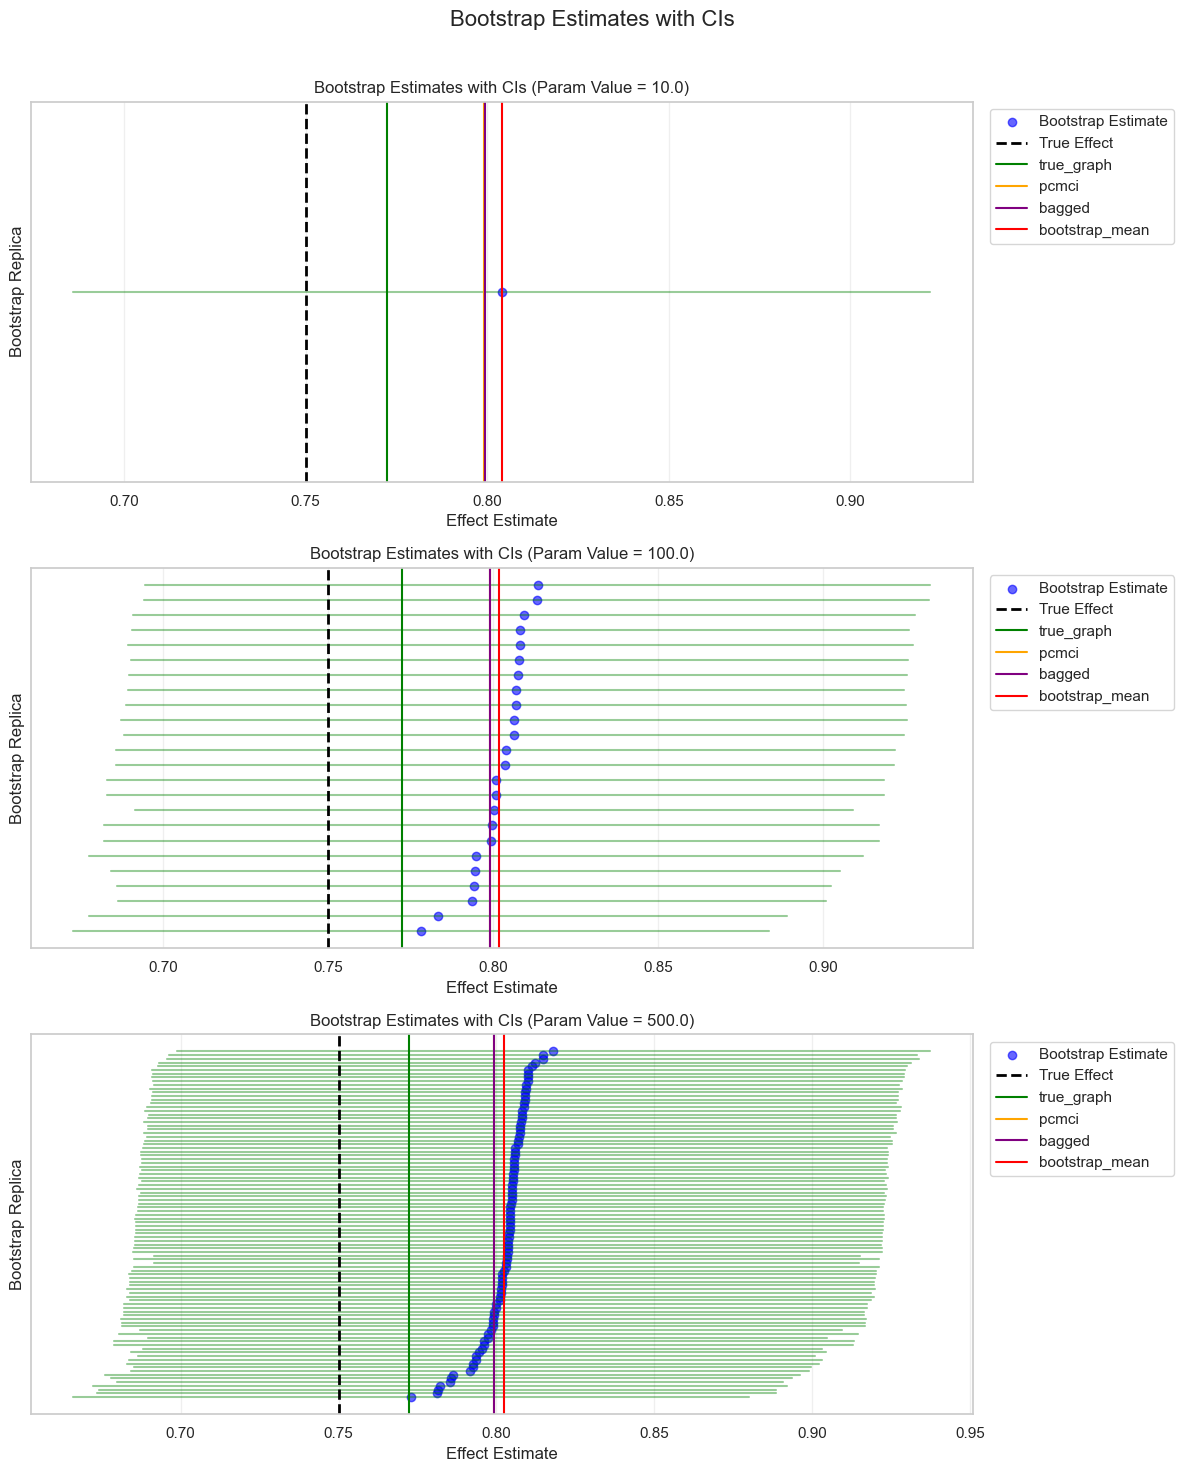

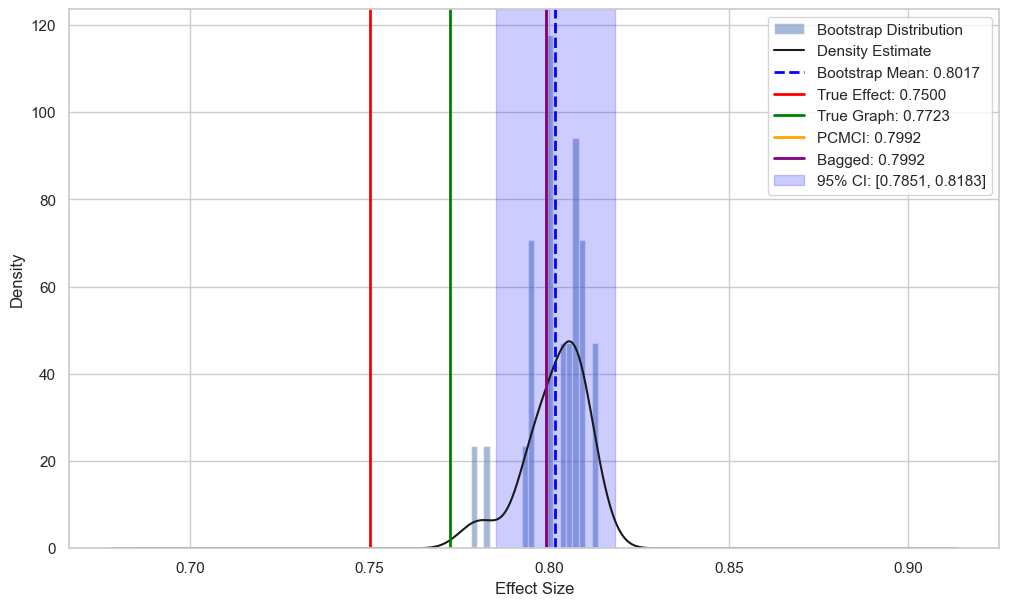

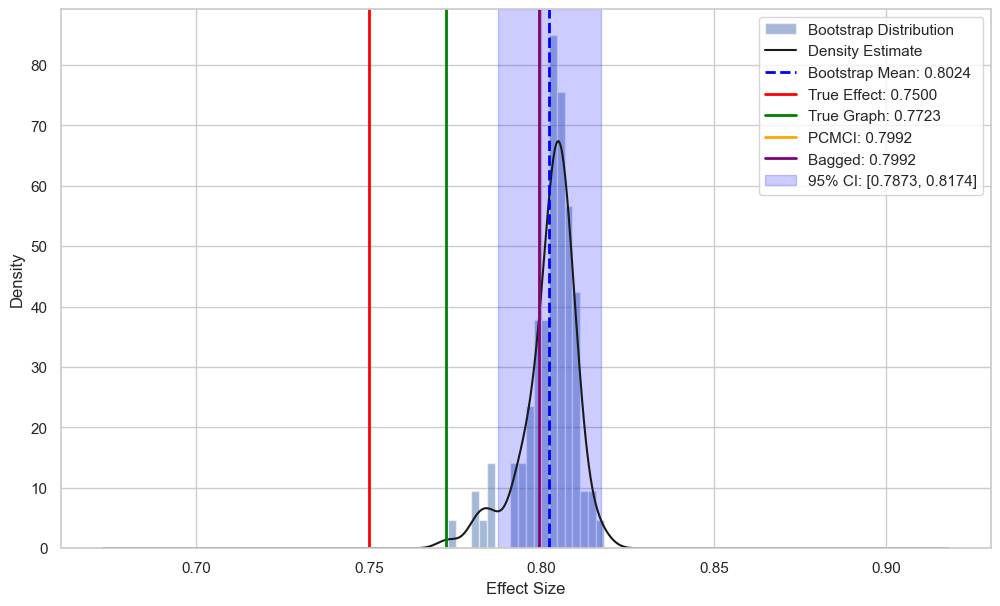

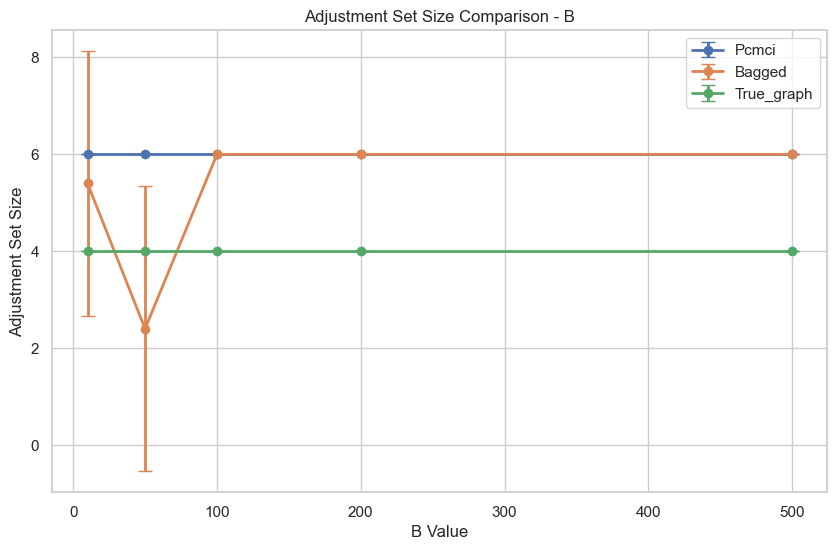

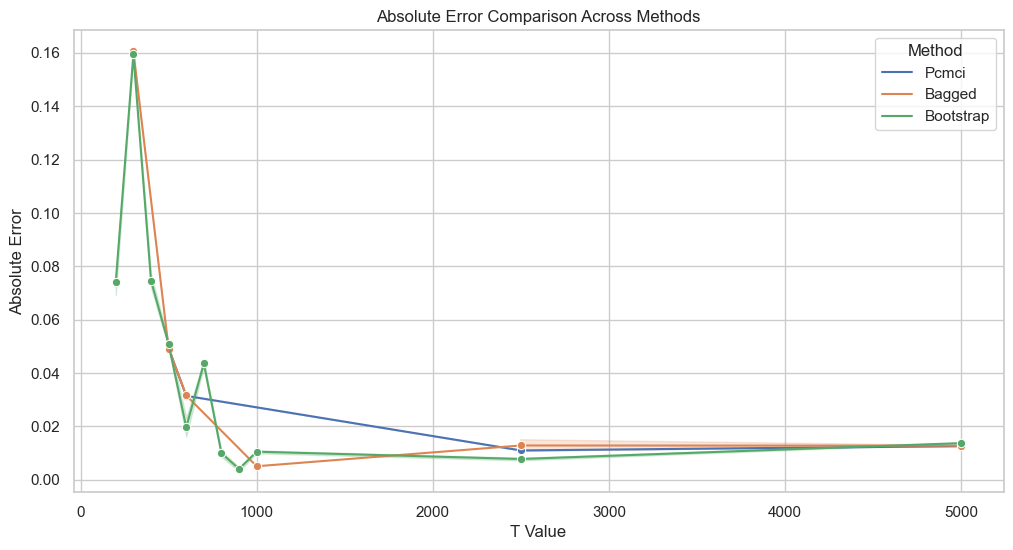

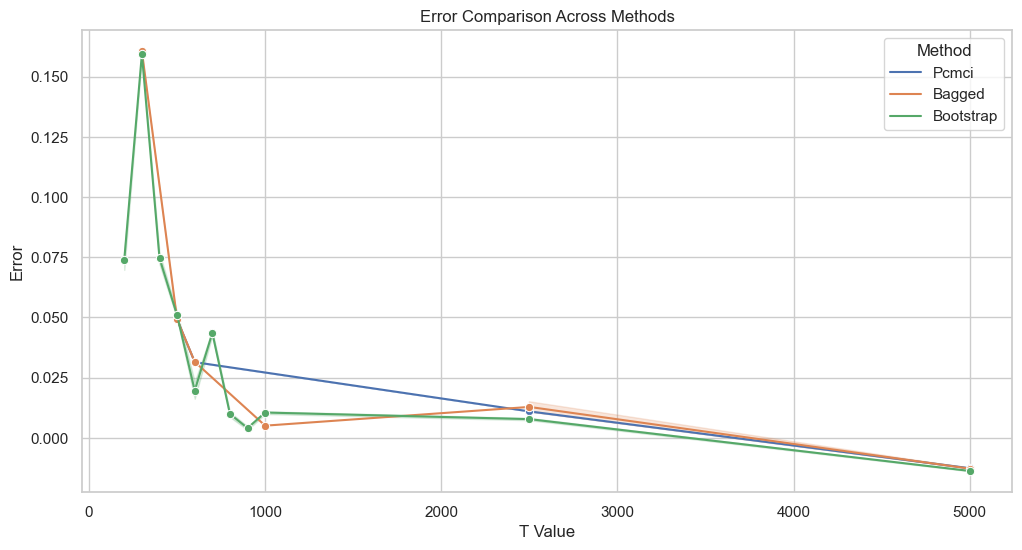

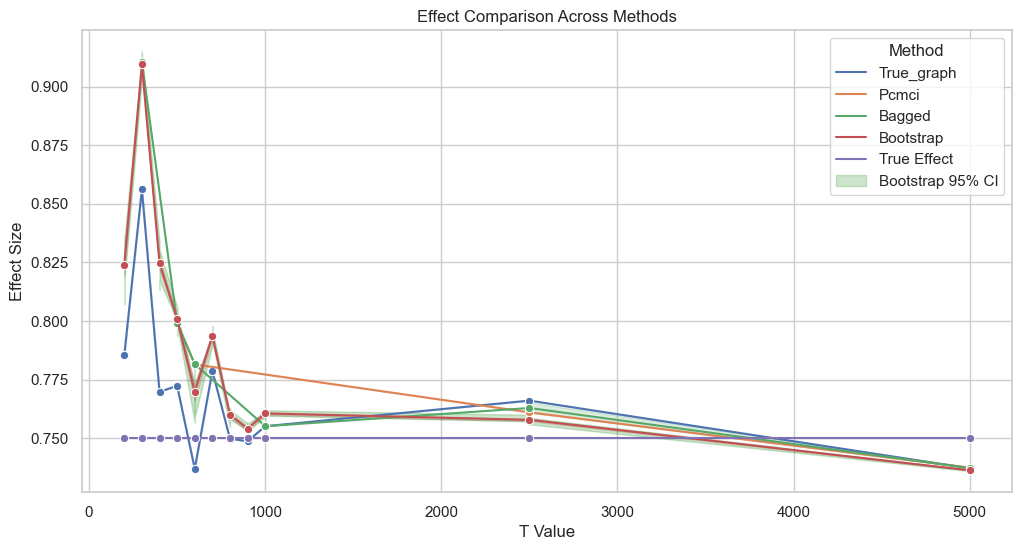

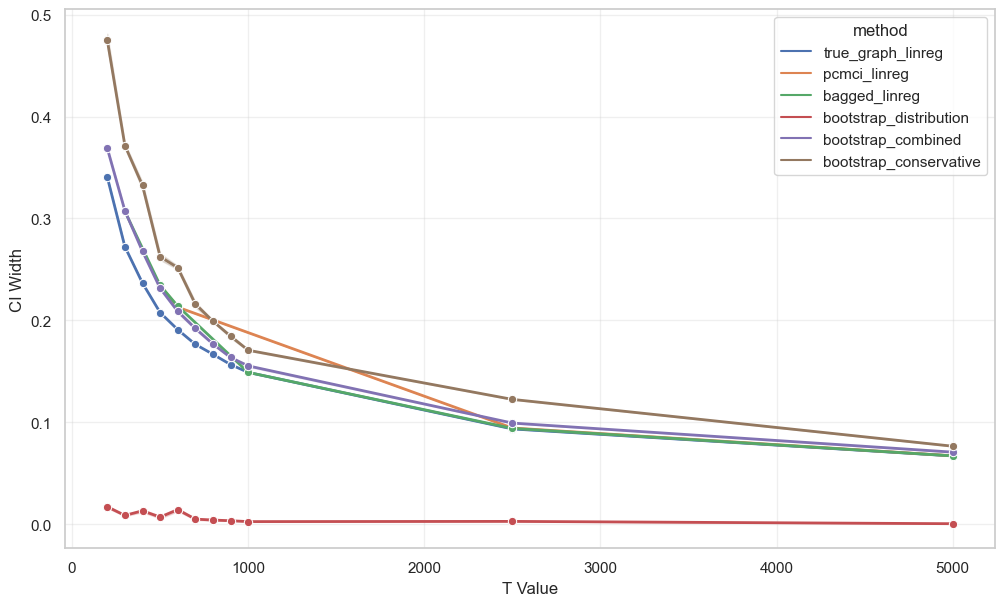

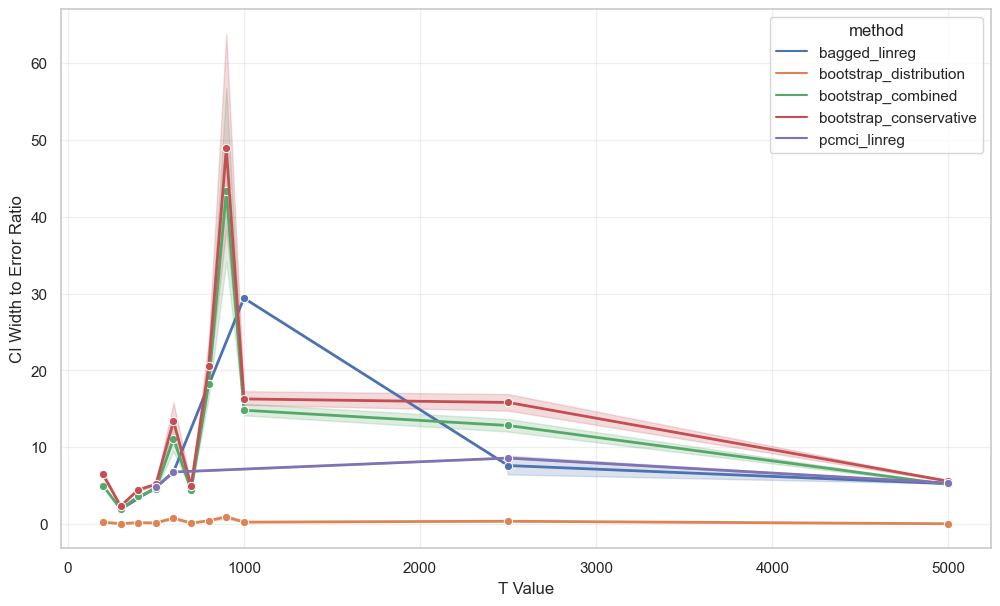

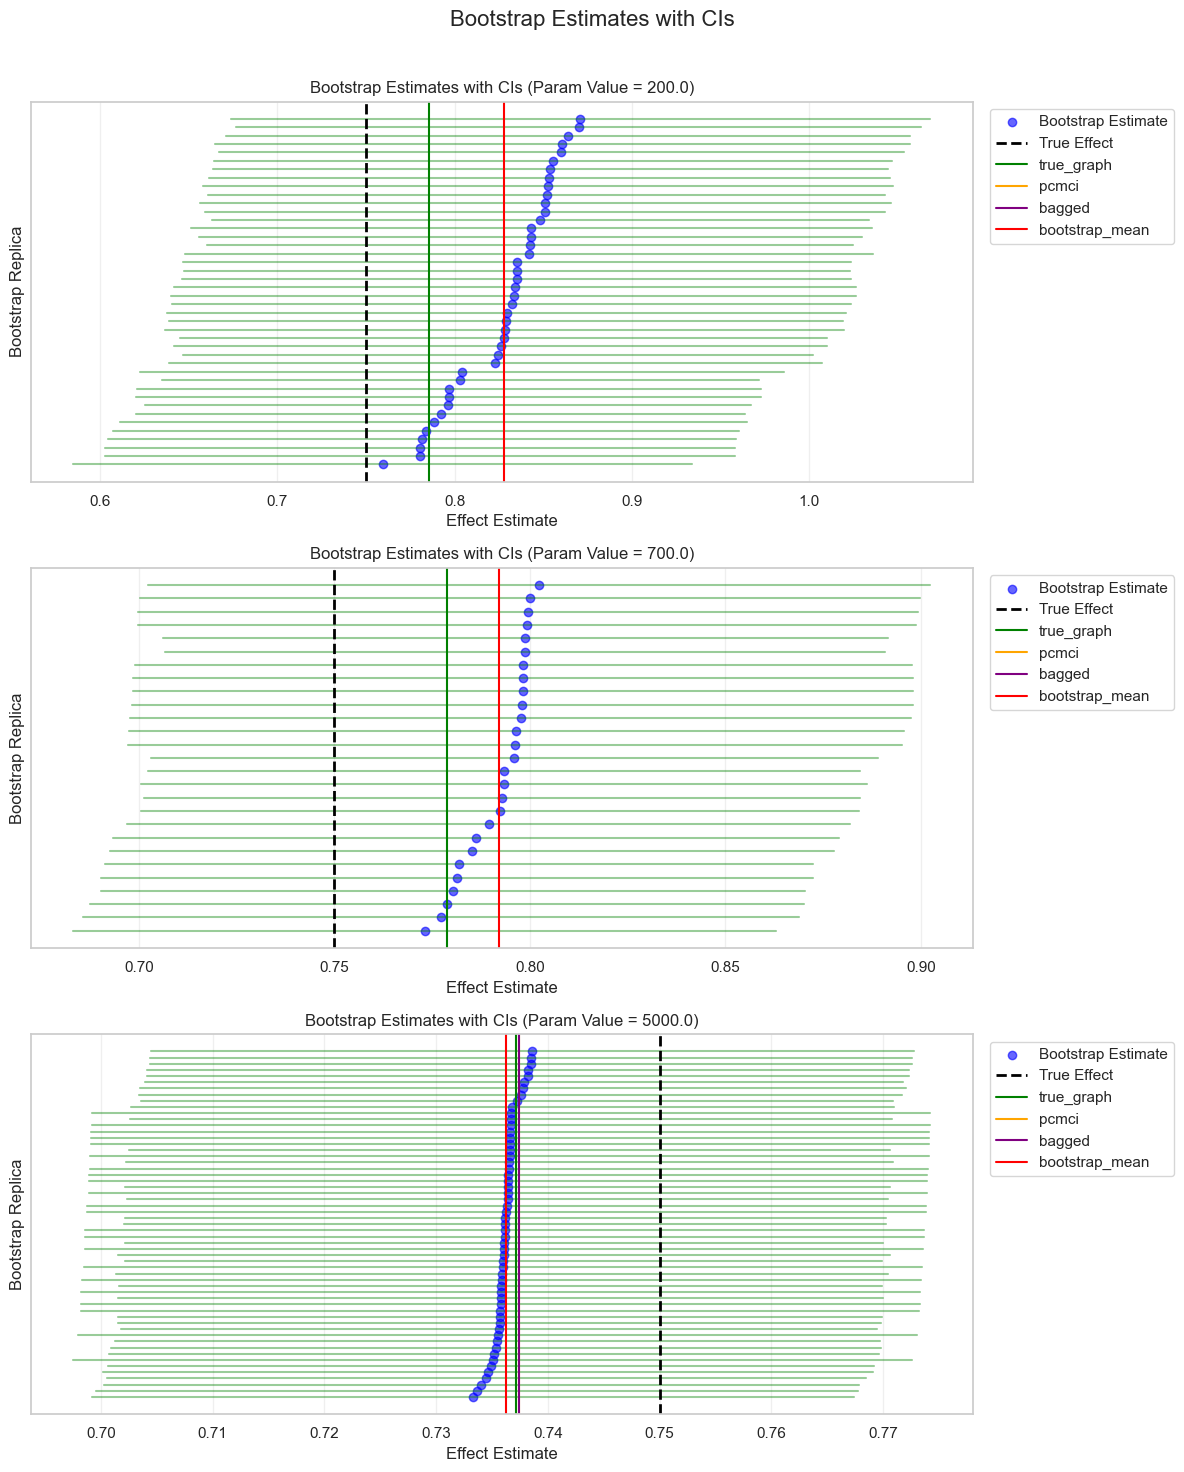

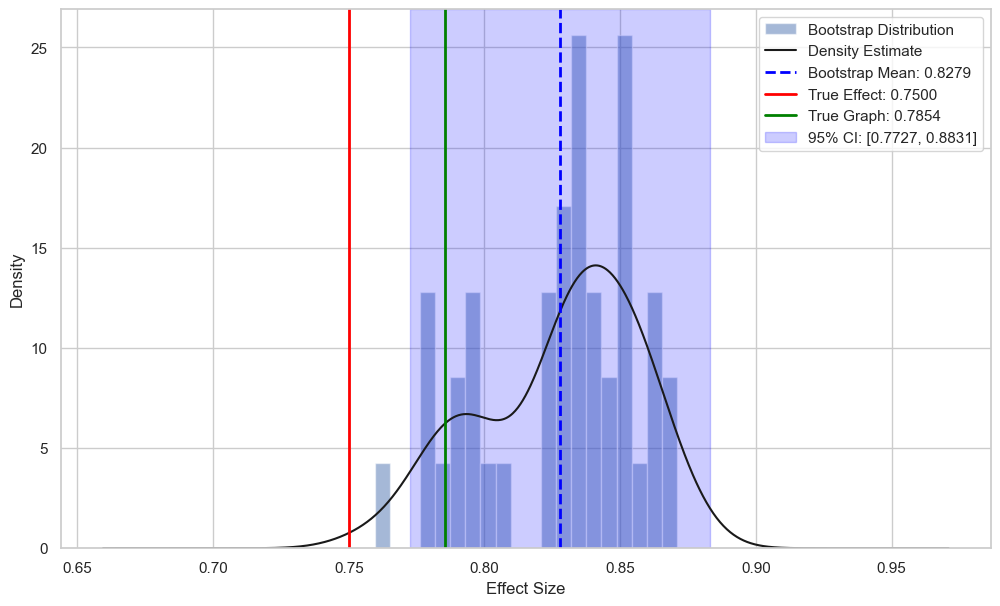

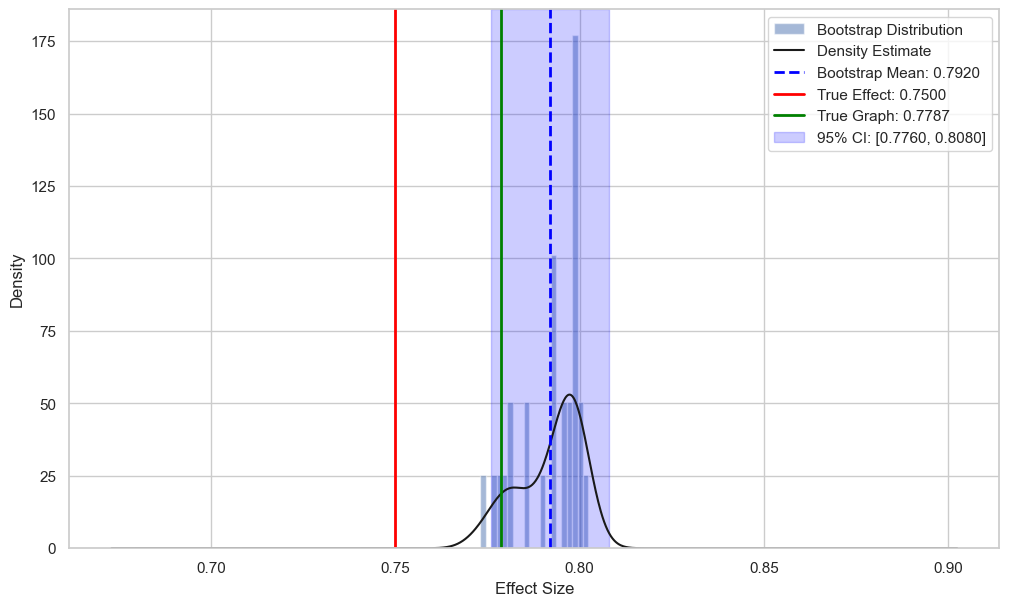

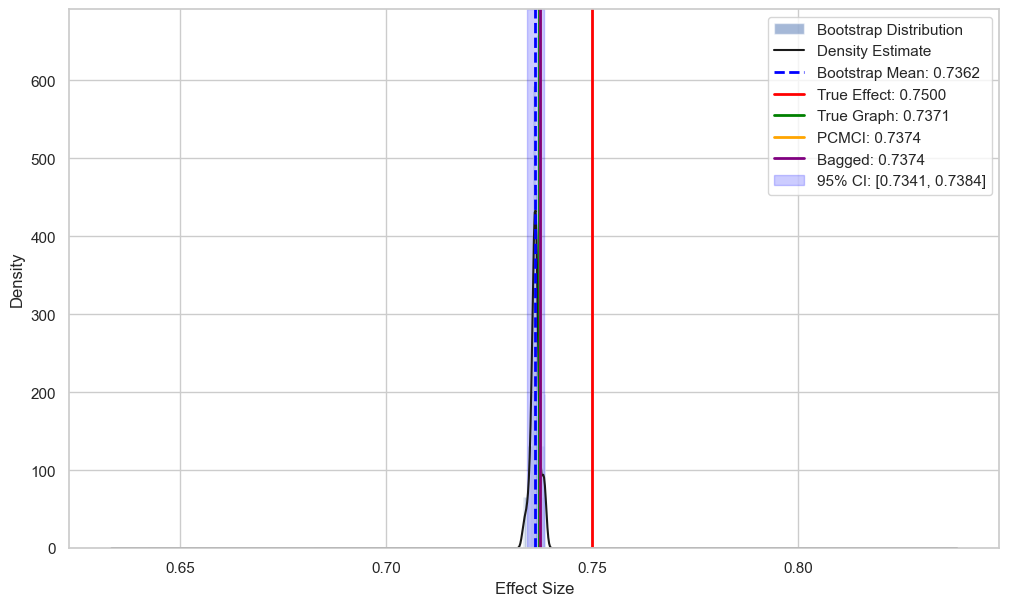

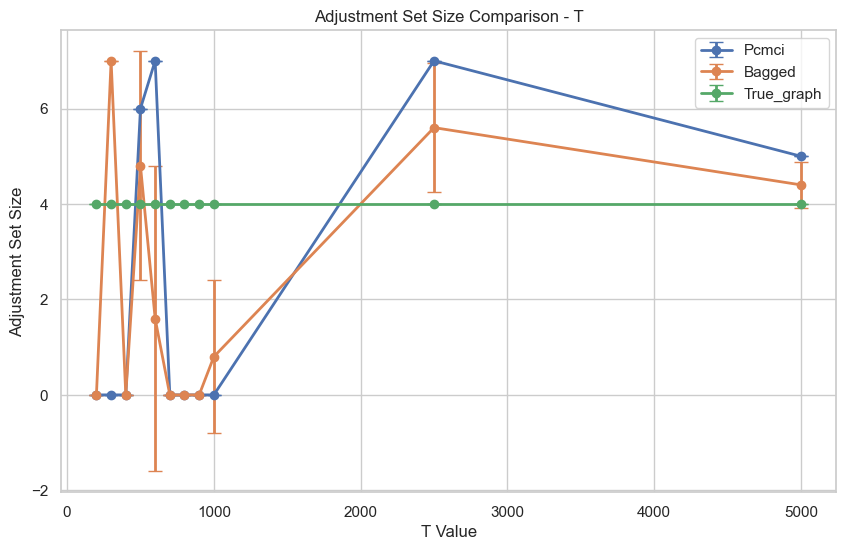

In [3]:
print("Loading study results and generating all plots...")
plot_info = generate_all_plots(main_study_folder, results_folder, studies)

## 3. Summary of Results

Display a summary of the results and the generated plots.

In [4]:
# Load the processed results for summary
all_results = pd.read_csv(os.path.join(results_folder, "all_results.csv"))

# Display summary statistics
print("\n=== Study Summary ===\n")
print(f"Total effects analyzed: {len(all_results)}")
print(f"Parameters: {all_results['param_name'].unique()}")
print(f"Effect pairs: {all_results['effect_key'].unique()}")

# Print summary of generated plots
print("\n=== Generated Plots ===\n")
for plot_type, studies_dict in plot_info.items():
    if studies_dict:  # If there are plots of this type
        print(f"\n{plot_type.capitalize()} plots:")
        for study, plots in studies_dict.items():
            if isinstance(plots, dict):
                print(f"  - {study}: {len(plots)} plots")
            else:
                print(f"  - {study}: {os.path.basename(plots)}")

print(f"\nAll results saved to: {results_folder}")


=== Study Summary ===

Total effects analyzed: 380
Parameters: ['a' 'c' 'sigmaN' 'B' 'T']
Effect pairs: ['0_-2_to_3_0']

=== Generated Plots ===


Pipeline plots:
  - T: Pipeline_timing.png

Ratio plots:
  - T: Ratio_timing.png

Replica plots:
  - n_boot: Pipeline_timing.png

Error plots:
  - a: 2 plots
  - c: 2 plots
  - sigmaN: 2 plots
  - B: 2 plots
  - T: 2 plots

Bootstrap plots:
  - a: 3 plots
  - c: 3 plots
  - sigmaN: 3 plots
  - B: 2 plots
  - T: 3 plots

Adjustment plots:
  - a: a_adjustment_sets.png
  - c: c_adjustment_sets.png
  - sigmaN: sigmaN_adjustment_sets.png
  - B: B_adjustment_sets.png
  - T: T_adjustment_sets.png

Error_vs_ci_width plots:
  - overall: overall_error_vs_ci_width.png

All results saved to: analysis_results_2025-04-08_11-50-02


## 4. Error Metrics

Calculate and display summary error metrics for each method and parameter.

In [5]:
# Group by parameter name and value
error_metrics = []
for param_name in all_results['param_name'].unique():
    for param_value in sorted(all_results[all_results['param_name'] == param_name]['param_value'].unique()):
        subset = all_results[(all_results['param_name'] == param_name) & 
                             (all_results['param_value'] == param_value)]
        
        # Calculate metrics for each method
        metrics = {'param_name': param_name, 'param_value': param_value}
        
        for method in ['pcmci', 'bagged', 'bootstrap']:
            error_col = f'{method}_abs_error'
            bias_col = f'{method}_error'
            
            if error_col in subset.columns:
                errors = subset[error_col].dropna()
                if len(errors) > 0:
                    metrics[f'{method}_mae'] = errors.mean()
                    metrics[f'{method}_rmse'] = np.sqrt((errors**2).mean())
            
            if bias_col in subset.columns:
                biases = subset[bias_col].dropna()
                if len(biases) > 0:
                    metrics[f'{method}_bias'] = biases.mean()
        
        # Add CI coverage if available
        if 'ci_covers_true' in subset.columns:
            coverage = subset['ci_covers_true'].dropna()
            if len(coverage) > 0:
                metrics['bootstrap_ci_coverage'] = coverage.mean()
        
        error_metrics.append(metrics)

# Convert to DataFrame and save
error_df = pd.DataFrame(error_metrics)
error_df.to_csv(os.path.join(results_folder, "error_metrics_summary.csv"), index=False)

# Display error metrics
print("\n=== Error Metrics Summary ===\n")
print(error_df)

# Create a simplified metrics table for each parameter
for param_name in error_df['param_name'].unique():
    param_df = error_df[error_df['param_name'] == param_name].copy()
    param_df = param_df.sort_values('param_value')
    
    # Select most important columns
    cols_to_display = ['param_value', 'pcmci_mae', 'bagged_mae', 'bootstrap_mae']
    if 'bootstrap_ci_coverage' in param_df.columns:
        cols_to_display.append('bootstrap_ci_coverage')
    
    # Display and save
    print(f"\n{param_name.capitalize()} study metrics:")
    print(param_df[cols_to_display])
    
    # Save to CSV
    param_df.to_csv(os.path.join(results_folder, f"{param_name}_metrics.csv"), index=False)


=== Error Metrics Summary ===

   param_name  param_value  pcmci_mae  pcmci_rmse  pcmci_bias  bagged_mae  \
0           a     0.010000   0.004387    0.004387   -0.004387    0.003686   
1           a     0.061579   0.054352    0.054352    0.054352    0.046140   
2           a     0.113158   0.056416    0.056416    0.056416    0.056416   
3           a     0.164737   0.056477    0.056477    0.056477    0.056477   
4           a     0.216316   0.056410    0.056410    0.056410    0.056410   
..        ...          ...        ...         ...         ...         ...   
71          T   800.000000        NaN         NaN         NaN         NaN   
72          T   900.000000        NaN         NaN         NaN         NaN   
73          T  1000.000000        NaN         NaN         NaN    0.005067   
74          T  2500.000000   0.010997    0.010997    0.010997    0.012849   
75          T  5000.000000   0.012604    0.012604   -0.012604    0.012778   

    bagged_rmse  bagged_bias  bootstrap_mae

## 5. Display Key Plots

Display some of the generated plots directly in the notebook.


=== Sample Plots ===


A absolute error:


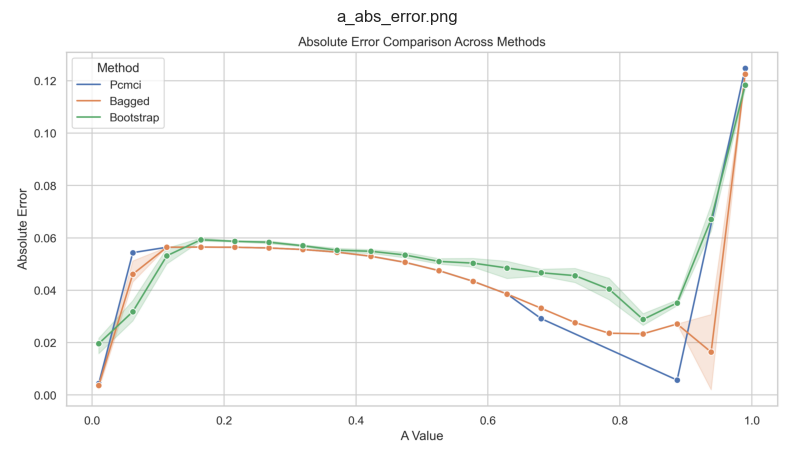


A bootstrap distribution:


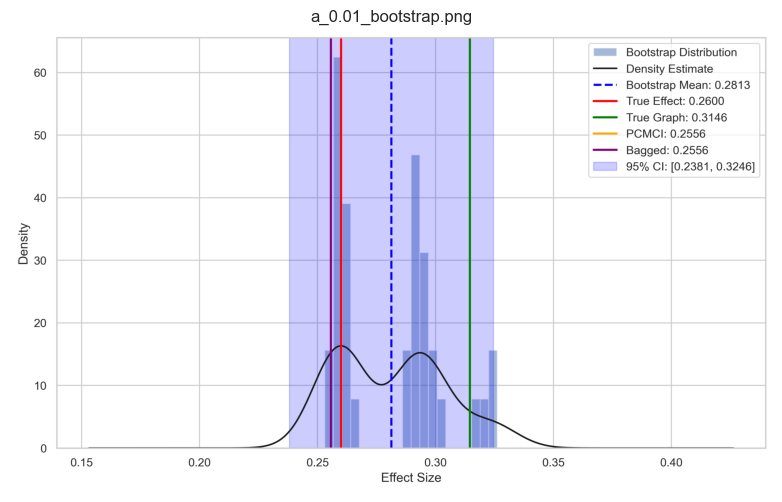


A adjustment sets:


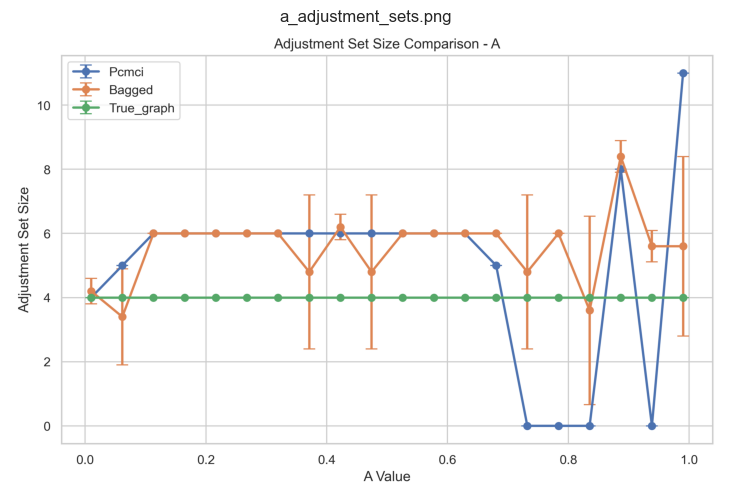


C absolute error:


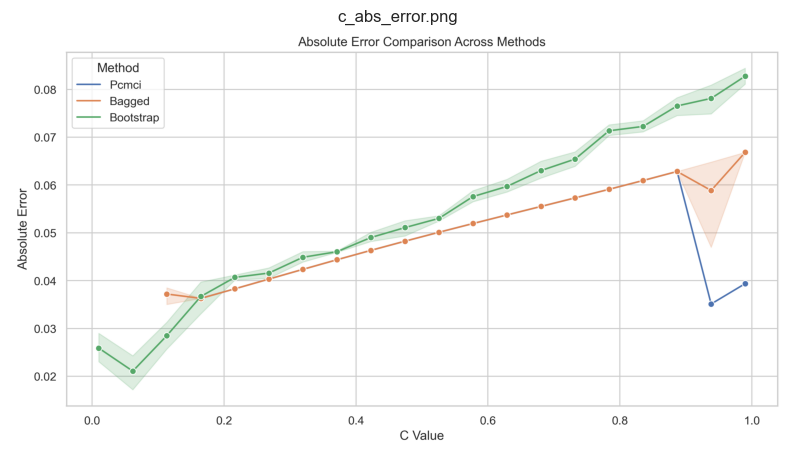


C bootstrap distribution:


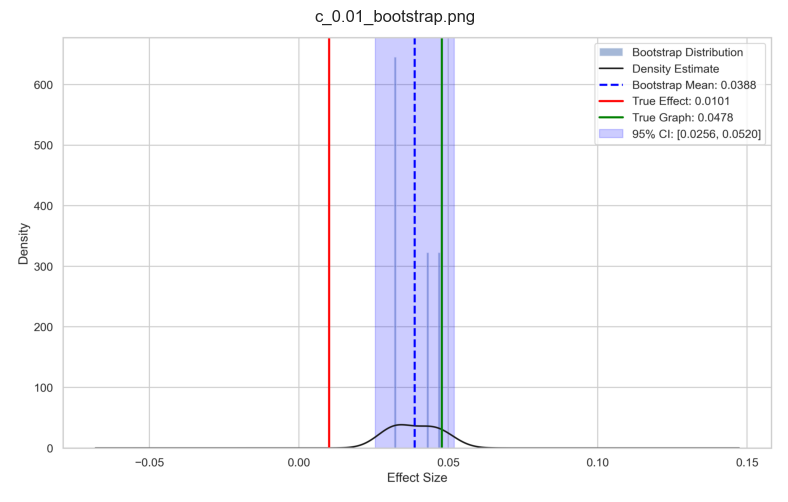


C adjustment sets:


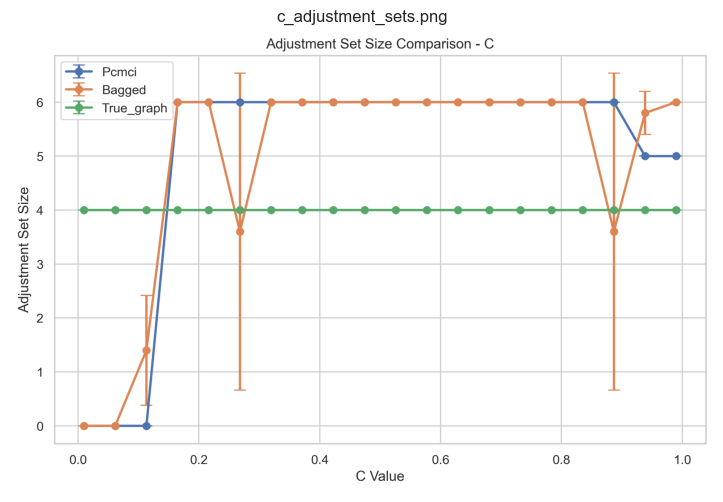


Sigman absolute error:


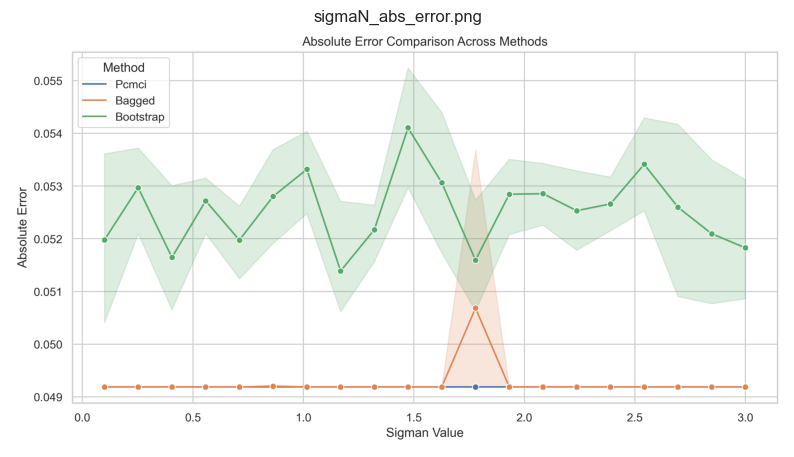


Sigman bootstrap distribution:


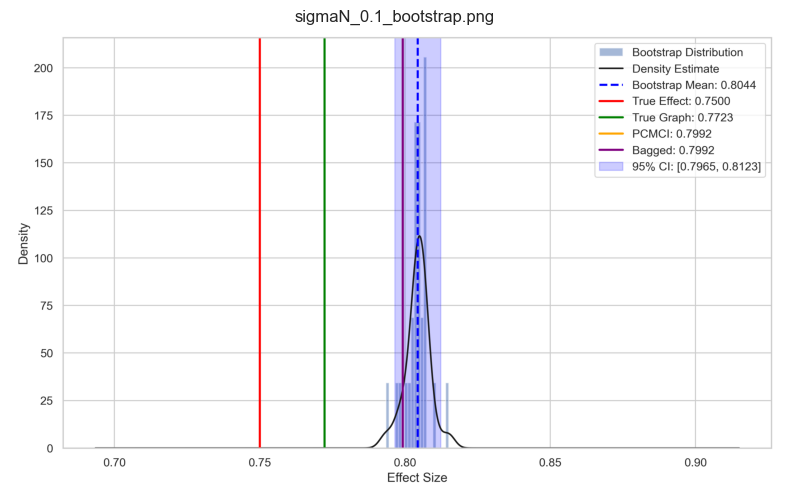


Sigman adjustment sets:


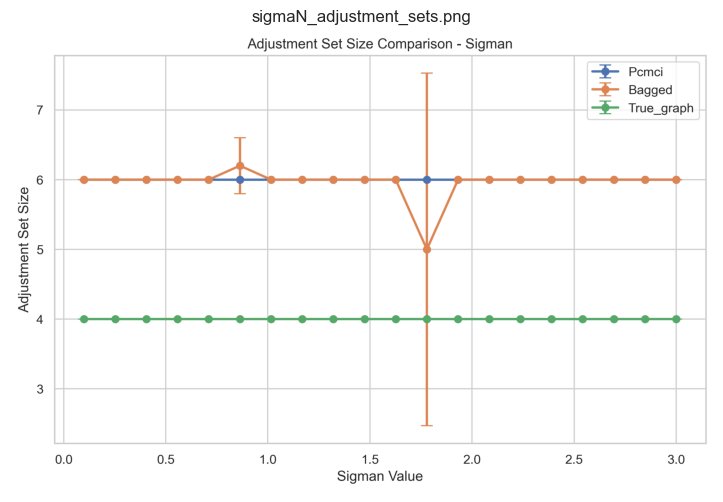


B absolute error:


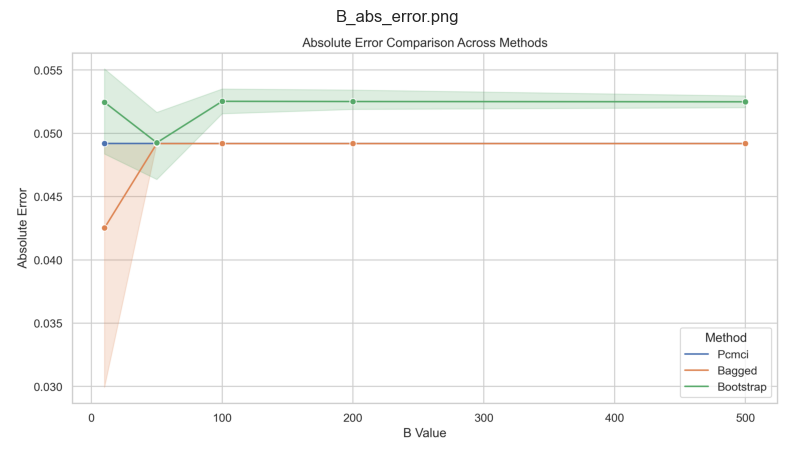


B bootstrap distribution:


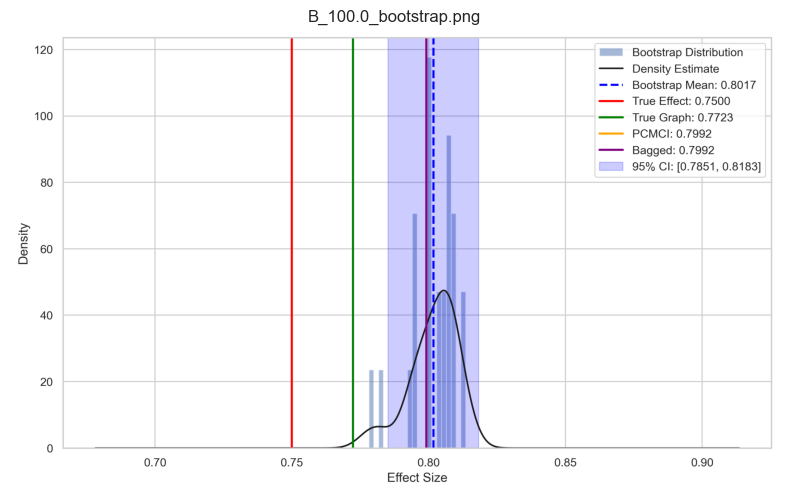


B adjustment sets:


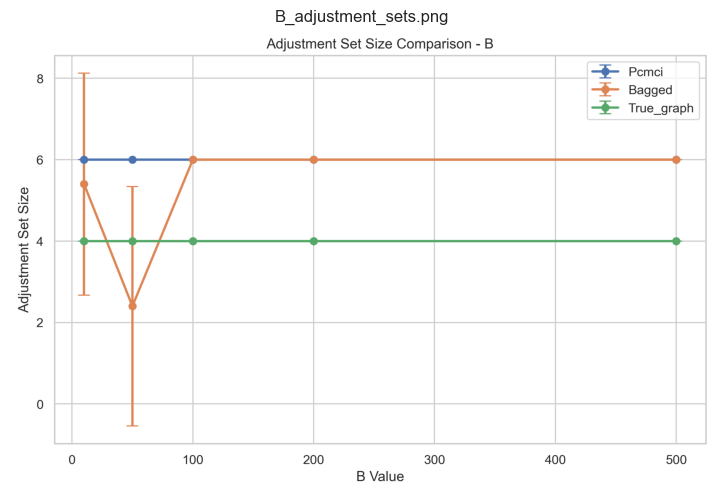


T absolute error:


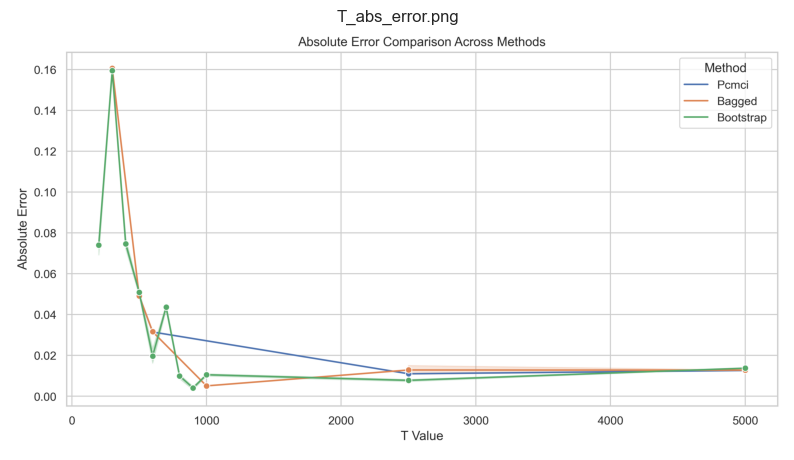


T bootstrap distribution:


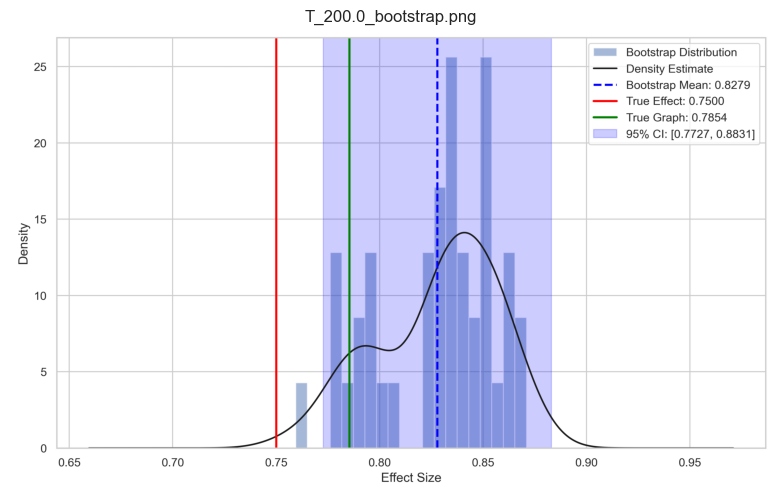


T adjustment sets:


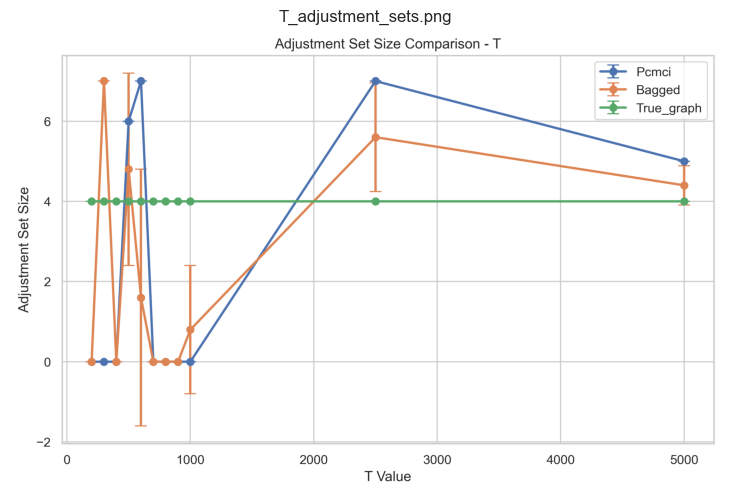

In [6]:
# Helper function to display plots
def display_plot(filepath, figsize=(10, 6)):
    """Display a plot from file in the notebook"""
    if not os.path.exists(filepath):
        print(f"Plot not found: {filepath}")
        return
    
    plt.figure(figsize=figsize)
    img = plt.imread(filepath)
    plt.imshow(img)
    plt.axis('off')
    plt.title(os.path.basename(filepath))
    plt.show()

# Display a selection of plots
print("\n=== Sample Plots ===\n")

# Display error plots for each parameter
for param_name in error_df['param_name'].unique():
    if param_name in plot_info['error'] and 'abs' in plot_info['error'][param_name]:
        print(f"\n{param_name.capitalize()} absolute error:")
        display_plot(plot_info['error'][param_name]['abs'])
    
    # Display a bootstrap distribution plot if available
    if param_name in plot_info['bootstrap'] and plot_info['bootstrap'][param_name]:
        # Get one bootstrap plot (the first one)
        bs_plot = next(iter(plot_info['bootstrap'][param_name].values()))
        print(f"\n{param_name.capitalize()} bootstrap distribution:")
        display_plot(bs_plot)
    
    # Display adjustment set plot if available
    if param_name in plot_info['adjustment']:
        print(f"\n{param_name.capitalize()} adjustment sets:")
        display_plot(plot_info['adjustment'][param_name])